In [ ]:
import os
import ast
import json
import pickle
import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt
from typing import List, Optional
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from Bio import Phylo
from scipy.stats import binom

In [1]:
_COMP_TABLE = str.maketrans("ACGTNacgtn", "TGCANtgcan")

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)


def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    trees = list(Phylo.parse(nexus_path, "nexus"))
    tree = trees[0] if tree_label is None else next(
        t for t in trees if t.name == tree_label
    )
    return [c.name for c in tree.find_clades(order="level") if c.is_terminal()]


phylogeneticOrder = ()
tips_bio = tip_order_from_nexus_biopython(
    "/LeeLab/HPRC/chromosomeY/Information/phylogeny/"
    "142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex"
)
for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)

goodYq12Samples = []
with open(
    '/LeeLab/HPRC/chromosomeY/QC/LocationFiles/Yq12_QC_File.txt', 'r'
) as inFile:
    for line in inFile:
        goodYq12Samples.append(line.strip())
print(f"Good Yq12 samples: {len(goodYq12Samples)}")

assemblyDict = {}
directory = '/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    assemblyDict[file.split("_")[0]] = directory + file
print(f"Assemblies loaded: {len(assemblyDict)}")

errorHits = {}
directory = '/LeeLab/HPRC/chromosomeY/Data/Mutations/QC/'
for file in os.listdir(directory):
    sample = file.split("_")[0]
    df = pd.read_csv(directory + file, sep='\t', header=None)
    for contig in set(df[0]):
        errorHits[contig] = []
    for row in df.index:
        span = str(df.at[row, 1]) + "-" + str(df.at[row, 2])
        errorHits[df.at[row, 0]].append(span)

yq12SubunitCoordinates = {}
directory = (
    '/LeeLab/HPRC/chromosomeY/Data/'
    'HMMER_Files/HMMER_Counts/yq12hmmerFilter/'
)
for file in os.listdir(directory):
    if '.csv' in file:
        try:
            sample = str(file.split(".")[0])
            df = pd.read_csv(directory + file)
            df2 = df[df['0'] == sample + "_chrY"].copy()
            yq12SubunitCoordinates[sample] = (
                str(sample + "_chrY") + ":" +
                str(min(df2['3'])) + "-" +
                str(max(df2['4']))
            )
        except Exception:
            print(file)

mutationDF = pd.read_csv(
    '/LeeLab/HPRC/chromosomeY/Data/Mutations/Pille_Yq12_DeNovo_SNVs_filt2_13Apr2026.csv'
)
snpDF   = mutationDF[mutationDF['Var_type'].isin(['snp', 'snv'])].copy()
DELDF   = mutationDF[mutationDF['Var_type'] == 'SV_DEL'].copy()
INSDF   = mutationDF[mutationDF['Var_type'] == 'SV_INS'].copy()

snpDF_yq12 = snpDF[
    snpDF['Location'].isin(['DYZ1', 'DYZ2'])
].copy()

print(f"Yq12 SNVs (all): {len(snpDF_yq12)}")


def revcomp(seq):
    return seq.translate(_COMP_TABLE)[::-1]


def complement_base(base):
    return base.translate(_COMP_TABLE)


def parse_region(region):
    chrom, coords = region.split(":")
    start, end = coords.split("-")
    return chrom, int(start), int(end)


def parse_start_end(region):
    start, end = region.split("-")
    return int(start), int(end)


def _fetch_seq_from_1based_inclusive(fasta_path, contig, start, end):
    start = max(1, int(start))
    end   = int(end)
    if end < start:
        return ""
    return "".join(
        pysam.faidx(fasta_path, f"{contig}:{start}-{end}").split()[1:]
    ).upper()


def _fetch_base_from_1based(fasta_path, contig, pos):
    return _fetch_seq_from_1based_inclusive(fasta_path, contig, pos, pos)


def _fetch_trinuc_from_1based(fasta_path, contig, pos):
    return _fetch_seq_from_1based_inclusive(fasta_path, contig, pos - 1, pos + 1)


def _get_base_from_cached_target_seq(target_seq, target_start_1based, pos_1based):
    idx0 = int(pos_1based) - int(target_start_1based)
    if 0 <= idx0 < len(target_seq):
        return target_seq[idx0]
    return None


def parse_python_object(x):
    """Convert stringified lists/dicts back to Python objects (used after CSV round-trips)."""
    if isinstance(x, (list, dict)):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if x in {"", "NONE", "None", "nan", "NaN"}:
            return []
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []


def _build_qc_cache(ErrorDict):
    qc_cache = {}
    if ErrorDict is None:
        return qc_cache
    for contig, regions in ErrorDict.items():
        parsed = []
        for region in regions:
            try:
                start, end = parse_start_end(region)
                parsed.append((int(start), int(end)))
            except Exception:
                continue
        qc_cache[contig] = parsed
    return qc_cache


def _overlaps_any_qc(qc_cache, target_contig, hit_start, hit_end):
    if not qc_cache or target_contig not in qc_cache:
        return False
    for start, end in qc_cache[target_contig]:
        if not (hit_end < start or hit_start > end):
            return True
    return False


def _find_all_exact_hits(seq, kmer):
    hits = []
    start = 0
    while True:
        pos = seq.find(kmer, start)
        if pos == -1:
            break
        hits.append(pos)
        start = pos + 1
    return hits


def _extend_flanks_excluding_center(query_seq, target_seq, qcenter, tcenter, min_flank):
    """Extend exact homology around the focal site, excluding the center base itself."""
    qlen = len(query_seq)
    tlen = len(target_seq)

    left_matched  = min_flank
    right_matched = min_flank

    ql, tl = qcenter - min_flank - 1, tcenter - min_flank - 1
    left_span_extra = 0
    while ql >= 0 and tl >= 0:
        if query_seq[ql] != target_seq[tl]:
            break
        left_matched    += 1
        left_span_extra += 1
        ql -= 1
        tl -= 1

    qr, tr = qcenter + min_flank + 1, tcenter + min_flank + 1
    right_span_extra = 0
    while qr < qlen and tr < tlen:
        if query_seq[qr] != target_seq[tr]:
            break
        right_matched    += 1
        right_span_extra += 1
        qr += 1
        tr += 1

    total_matched      = left_matched + right_matched
    target_full_start0 = tcenter - left_matched
    target_full_end0   = tcenter + right_matched

    return {
        "left_matched":        left_matched,
        "right_matched":       right_matched,
        "left_mismatches":     0,
        "right_mismatches":    0,
        "left_span":           left_span_extra,
        "right_span":          right_span_extra,
        "seed_len":            2 * min_flank,
        "total_matched":       total_matched,
        "total_mismatches":    0,
        "score":               total_matched,
        "target_full_start0":  target_full_start0,
        "target_full_end0":    target_full_end0,
        "center_excluded":     True,
    }


def _find_flank_only_hits(
    *,
    query_seq,
    target_seq,
    target_contig,
    target_start_1based,
    locus_pos,
    min_flank,
    include_revcomp,
    qc_cache,
    remove_self_hit,
    remove_nearby_bp,
    original_center_1based,
    max_hits_per_kmer=None,
    min_homology: int = 150,
):
    _empty = {
        "best_score": None, "kept_hits": [], "all_best_hits": [],
        "seed_length": None,
        "n_seed_hits_plus": 0,  "n_seed_hits_minus": 0,
        "n_left_seed_hits_plus": 0,  "n_right_seed_hits_plus": 0,
        "n_left_seed_hits_minus": 0, "n_right_seed_hits_minus": 0,
    }

    if not query_seq:
        return _empty

    qlen    = len(query_seq)
    qcenter = qlen // 2

    left_seed_start = qcenter - min_flank
    right_seed_end  = qcenter + min_flank

    if left_seed_start < 0 or right_seed_end >= qlen:
        return {**_empty, "seed_length": 2 * min_flank}

    def scan_one_strand(qseq, strand):
        left_seed  = qseq[left_seed_start:qcenter]
        right_seed = qseq[qcenter + 1:right_seed_end + 1]

        left_hits  = _find_all_exact_hits(target_seq, left_seed)
        right_hits = _find_all_exact_hits(target_seq, right_seed)

        if max_hits_per_kmer is not None:
            left_hits  = left_hits[:max_hits_per_kmer]
            right_hits = right_hits[:max_hits_per_kmer]

        right_hit_set = set(right_hits)
        candidates    = []
        seen_centers  = set()

        for left_hit_start in left_hits:
            tcenter              = left_hit_start + min_flank
            expected_right_start = tcenter + 1

            if expected_right_start not in right_hit_set:
                continue
            if tcenter in seen_centers:
                continue
            seen_centers.add(tcenter)

            rec = _extend_flanks_excluding_center(
                query_seq=qseq, target_seq=target_seq,
                qcenter=qcenter, tcenter=tcenter, min_flank=min_flank,
            )

            hit_start  = target_start_1based + rec["target_full_start0"]
            hit_end    = target_start_1based + rec["target_full_end0"]
            hit_center = target_start_1based + tcenter

            if remove_self_hit and hit_center == original_center_1based:
                continue
            if remove_nearby_bp is not None and abs(hit_center - original_center_1based) < remove_nearby_bp:
                continue
            if _overlaps_any_qc(qc_cache, target_contig, hit_start, hit_end):
                continue

            candidates.append({
                "coord":    f"{target_contig}:{hit_start}-{hit_end}({strand})",
                "contig":   target_contig,
                "start":    int(hit_start),
                "end":      int(hit_end),
                "center":   int(hit_center),
                "strand":   strand,
                "dist_bp":  int(hit_center - locus_pos),
                **{k: (int(v) if isinstance(v, (np.integer,)) else
                       bool(v) if isinstance(v, (np.bool_,)) else v)
                   for k, v in rec.items()},
            })

        return candidates, len(left_hits), len(right_hits)

    plus_hits, n_plus_left, n_plus_right = scan_one_strand(query_seq, "+")
    all_hits = list(plus_hits)

    minus_hits, n_minus_left, n_minus_right = [], 0, 0
    if include_revcomp:
        minus_hits, n_minus_left, n_minus_right = scan_one_strand(revcomp(query_seq), "-")
        all_hits.extend(minus_hits)

    if not all_hits:
        return {
            "best_score": None, "kept_hits": [], "all_best_hits": [],
            "seed_length":          2 * min_flank,
            "n_seed_hits_plus":     len(plus_hits),
            "n_seed_hits_minus":    len(minus_hits),
            "n_left_seed_hits_plus":  n_plus_left,
            "n_right_seed_hits_plus": n_plus_right,
            "n_left_seed_hits_minus":  n_minus_left,
            "n_right_seed_hits_minus": n_minus_right,
        }

    best_score      = max(h["score"] for h in all_hits)
    qualifying_hits = [h for h in all_hits if h["total_matched"] >= min_homology]

    if not qualifying_hits:
        return {
            "best_score": best_score, "kept_hits": [], "all_best_hits": [],
            "seed_length":          2 * min_flank,
            "n_seed_hits_plus":     len(plus_hits),
            "n_seed_hits_minus":    len(minus_hits),
            "n_left_seed_hits_plus":  n_plus_left,
            "n_right_seed_hits_plus": n_plus_right,
            "n_left_seed_hits_minus":  n_minus_left,
            "n_right_seed_hits_minus": n_minus_right,
        }

    kept_hits = sorted(qualifying_hits, key=lambda x: (-x["total_matched"], abs(x["dist_bp"])))

    return {
        "best_score":    best_score,
        "kept_hits":     kept_hits[:1],
        "all_best_hits": kept_hits,
        "seed_length":   2 * min_flank,
        "n_seed_hits_plus":     len(plus_hits),
        "n_seed_hits_minus":    len(minus_hits),
        "n_left_seed_hits_plus":  n_plus_left,
        "n_right_seed_hits_plus": n_plus_right,
        "n_left_seed_hits_minus":  n_minus_left,
        "n_right_seed_hits_minus": n_minus_right,
    }


def _build_candidate_donors(hit_list, target_yq12):
    donors = []
    for h in hit_list:
        donor_focal_pos = h["center"]
        donor_allele = _get_base_from_cached_target_seq(
            target_seq=target_yq12["seq"],
            target_start_1based=target_yq12["start"],
            pos_1based=donor_focal_pos,
        )
        if donor_allele is not None and h["strand"] == "-":
            donor_allele = complement_base(donor_allele)

        donors.append({
            "copy_id":         h["coord"],
            "contig":          h["contig"],
            "start":           h["start"],
            "end":             h["end"],
            "strand":          h["strand"],
            "donor_focal_pos": donor_focal_pos,
            "allele":          donor_allele,
            "homology_bp":     h["total_matched"],
            "distance_bp":     h["dist_bp"],
            "left_matched":    h["left_matched"],
            "right_matched":   h["right_matched"],
            "score":           h["score"],
        })
    return donors


def _process_one_snv_row(args):
    (row_idx, row_data, assemblyDict, yq12SubunitCoordinates,
     min_flank, max_flank, include_revcomp, max_hits_per_kmer,
     remove_self_hit, remove_nearby_bp, qc_cache, yq12_cache,
     min_homology) = args

    son    = str(row_data["Son_ID"])
    father = str(row_data["chr_REF"]).split("_")[0]

    son_contig       = str(row_data["chr_SON"])
    father_contig    = str(row_data["chr_REF"])
    son_locus_pos    = int(row_data["end_SON"])
    father_locus_pos = int(row_data["end_REF"])

    son_yq12    = yq12_cache[son]
    father_yq12 = yq12_cache[father]

    son_fa    = pysam.FastaFile(assemblyDict[son])
    father_fa = pysam.FastaFile(assemblyDict[father])

    try:
        son_query = son_fa.fetch(son_contig,
                                 son_locus_pos - max_flank - 1,
                                 son_locus_pos + max_flank).upper()

        son_allele            = son_fa.fetch(son_contig, son_locus_pos - 1, son_locus_pos).upper()
        father_allele         = father_fa.fetch(father_contig, father_locus_pos - 1, father_locus_pos).upper()
        father_trinuc_context = father_fa.fetch(father_contig, father_locus_pos - 2, father_locus_pos + 1).upper()
    finally:
        son_fa.close()
        father_fa.close()

    son_scan = _find_flank_only_hits(
        query_seq=son_query, target_seq=son_yq12["seq"],
        target_contig=son_yq12["contig"], target_start_1based=son_yq12["start"],
        locus_pos=son_locus_pos, min_flank=min_flank,
        include_revcomp=include_revcomp, qc_cache=qc_cache,
        remove_self_hit=remove_self_hit, remove_nearby_bp=remove_nearby_bp,
        original_center_1based=son_locus_pos, max_hits_per_kmer=max_hits_per_kmer,
        min_homology=min_homology,
    )
    father_scan = _find_flank_only_hits(
        query_seq=son_query, target_seq=father_yq12["seq"],
        target_contig=father_yq12["contig"], target_start_1based=father_yq12["start"],
        locus_pos=father_locus_pos, min_flank=min_flank,
        include_revcomp=include_revcomp, qc_cache=qc_cache,
        remove_self_hit=remove_self_hit, remove_nearby_bp=remove_nearby_bp,
        original_center_1based=father_locus_pos, max_hits_per_kmer=max_hits_per_kmer,
        min_homology=min_homology,
    )

    best_son_hit    = son_scan["kept_hits"][0]    if son_scan["kept_hits"]    else None
    best_father_hit = father_scan["kept_hits"][0] if father_scan["kept_hits"] else None

    son_candidate_donors    = _build_candidate_donors(son_scan["all_best_hits"],    son_yq12)
    father_candidate_donors = _build_candidate_donors(father_scan["all_best_hits"], father_yq12)

    def _hv(hit, key):
        return None if hit is None else hit[key]

    return {
        "row": row_idx, "Son_ID": son, "Father_ID": father,
        "chr_SON": son_contig, "chr_REF": father_contig,
        "son_locus_pos": son_locus_pos, "father_locus_pos": father_locus_pos,
        "son_allele": son_allele, "father_allele": father_allele,
        "father_trinuc_context": father_trinuc_context,
        "sonyq12Coordinate": son_yq12["coord"], "fatheryq12Coordinate": father_yq12["coord"],
        "min_flank": min_flank, "max_flank": max_flank,
        "seed_length": 2 * min_flank, "center_excluded": True,
        "sonCoordinate":    f"{son_contig}:{son_locus_pos - max_flank}-{son_locus_pos + max_flank}",
        "fatherCoordinate": f"{father_contig}:{father_locus_pos - max_flank}-{father_locus_pos + max_flank}",
        "son_query": son_query,
        "son_seed_hits_plus":          son_scan["n_seed_hits_plus"],
        "son_seed_hits_minus":         son_scan["n_seed_hits_minus"],
        "father_seed_hits_plus":       father_scan["n_seed_hits_plus"],
        "father_seed_hits_minus":      father_scan["n_seed_hits_minus"],
        "son_left_seed_hits_plus":     son_scan["n_left_seed_hits_plus"],
        "son_right_seed_hits_plus":    son_scan["n_right_seed_hits_plus"],
        "son_left_seed_hits_minus":    son_scan["n_left_seed_hits_minus"],
        "son_right_seed_hits_minus":   son_scan["n_right_seed_hits_minus"],
        "father_left_seed_hits_plus":  father_scan["n_left_seed_hits_plus"],
        "father_right_seed_hits_plus": father_scan["n_right_seed_hits_plus"],
        "father_left_seed_hits_minus": father_scan["n_left_seed_hits_minus"],
        "father_right_seed_hits_minus":father_scan["n_right_seed_hits_minus"],
        "best_son_hit_coord":            _hv(best_son_hit, "coord"),
        "best_son_hit_score":            _hv(best_son_hit, "score"),
        "best_son_hit_total_matched":    _hv(best_son_hit, "total_matched"),
        "best_son_hit_total_mismatches": _hv(best_son_hit, "total_mismatches"),
        "best_son_hit_left_matched":     _hv(best_son_hit, "left_matched"),
        "best_son_hit_right_matched":    _hv(best_son_hit, "right_matched"),
        "best_son_hit_left_mismatches":  _hv(best_son_hit, "left_mismatches"),
        "best_son_hit_right_mismatches": _hv(best_son_hit, "right_mismatches"),
        "best_son_hit_left_span":        _hv(best_son_hit, "left_span"),
        "best_son_hit_right_span":       _hv(best_son_hit, "right_span"),
        "best_son_hit_dist_bp":          _hv(best_son_hit, "dist_bp"),
        "best_son_hit_strand":           _hv(best_son_hit, "strand"),
        "best_son_hit_center":           _hv(best_son_hit, "center"),
        "best_father_hit_coord":            _hv(best_father_hit, "coord"),
        "best_father_hit_score":            _hv(best_father_hit, "score"),
        "best_father_hit_total_matched":    _hv(best_father_hit, "total_matched"),
        "best_father_hit_total_mismatches": _hv(best_father_hit, "total_mismatches"),
        "best_father_hit_left_matched":     _hv(best_father_hit, "left_matched"),
        "best_father_hit_right_matched":    _hv(best_father_hit, "right_matched"),
        "best_father_hit_left_mismatches":  _hv(best_father_hit, "left_mismatches"),
        "best_father_hit_right_mismatches": _hv(best_father_hit, "right_mismatches"),
        "best_father_hit_left_span":        _hv(best_father_hit, "left_span"),
        "best_father_hit_right_span":       _hv(best_father_hit, "right_span"),
        "best_father_hit_dist_bp":          _hv(best_father_hit, "dist_bp"),
        "best_father_hit_strand":           _hv(best_father_hit, "strand"),
        "best_father_hit_center":           _hv(best_father_hit, "center"),
        "all_best_son_hits":       son_scan["all_best_hits"],
        "all_best_father_hits":    father_scan["all_best_hits"],
        "son_candidate_donors":    son_candidate_donors,
        "father_candidate_donors": father_candidate_donors,
    }


def test_gene_conversion_sites(
    snpDF: pd.DataFrame,
    assemblyDict: dict,
    yq12SubunitCoordinates: dict,
    *,
    min_flank: int,
    max_flank: int,
    include_revcomp: bool = True,
    max_hits_per_kmer: int | None = None,
    remove_self_hit: bool = True,
    remove_nearby_bp: int | None = None,
    ErrorDict: dict | None = None,
    n_workers: int = 4,
    min_homology: int = 150,
) -> pd.DataFrame:

    min_flank = int(min_flank)
    max_flank = int(max_flank)
    if min_flank < 0:
        raise ValueError("min_flank must be >= 0")
    if max_flank < min_flank:
        raise ValueError("max_flank must be >= min_flank")

    qc_cache = _build_qc_cache(ErrorDict)

    print("Pre-loading Yq12 sequences...")
    yq12_cache = {}
    all_samples = set()
    rows_data = snpDF.to_dict(orient="records")
    for r in rows_data:
        all_samples.add(str(r["Son_ID"]))
        all_samples.add(str(r["chr_REF"]).split("_")[0])
    for sample in all_samples:
        if sample in yq12SubunitCoordinates and sample in assemblyDict:
            coord              = yq12SubunitCoordinates[sample]
            contig, start, end = parse_region(coord)
            seq                = _fetch_seq_from_1based_inclusive(assemblyDict[sample], contig, start, end)
            yq12_cache[sample] = {"coord": coord, "contig": contig, "start": start, "end": end, "seq": seq}
    print(f"  cached {len(yq12_cache)} Yq12 sequences")

    args_list = [
        (
            snpDF.index[i], rows_data[i],
            assemblyDict, yq12SubunitCoordinates,
            min_flank, max_flank, include_revcomp,
            max_hits_per_kmer, remove_self_hit, remove_nearby_bp,
            qc_cache, yq12_cache, min_homology,
        )
        for i in range(len(rows_data))
    ]

    results = [None] * len(args_list)

    print(f"Running donor discovery on {len(args_list)} SNVs with {n_workers} workers...")
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_process_one_snv_row, a): idx
                   for idx, a in enumerate(args_list)}
        for future in as_completed(futures):
            idx = futures[future]
            results[idx] = future.result()

    return pd.DataFrame(results)


def build_event_table_from_gc_candidates(
    df,
    assemblyDict,
    son_id_col="Son_ID",
    father_id_col="Father_ID",
    son_pos_col="son_locus_pos",
    father_pos_col="father_locus_pos",
    son_contig_col="chr_SON",
    father_contig_col="chr_REF",
    reuse_existing_if_present=True,
):
    out = df.copy().reset_index(drop=True)

    if "event_id" not in out.columns:
        out["event_id"] = out["row"].astype(str) if "row" in out.columns else out.index.astype(str)

    missing = [c for c in [son_id_col, father_id_col, son_pos_col, father_pos_col,
                            son_contig_col, father_contig_col] if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if reuse_existing_if_present and all(
        c in out.columns for c in ["son_allele", "father_allele", "father_trinuc_context"]
    ):
        return out.rename(columns={"father_trinuc_context": "trinuc_context"})

    son_alleles, father_alleles, trinucs = [], [], []
    fasta_cache = {}

    def get_fasta(sample_id):
        sample_id = str(sample_id)
        if sample_id not in fasta_cache:
            fasta_cache[sample_id] = pysam.FastaFile(assemblyDict[sample_id])
        return fasta_cache[sample_id]

    for _, row in out.iterrows():
        son_fa    = get_fasta(str(row[son_id_col]))
        father_fa = get_fasta(str(row[father_id_col]))
        son_pos    = int(row[son_pos_col])
        father_pos = int(row[father_pos_col])

        son_alleles.append(son_fa.fetch(row[son_contig_col], son_pos - 1, son_pos).upper())
        father_alleles.append(father_fa.fetch(row[father_contig_col], father_pos - 1, father_pos).upper())
        trinucs.append(father_fa.fetch(row[father_contig_col], father_pos - 2, father_pos + 1).upper())

    for fa in fasta_cache.values():
        fa.close()

    out["son_allele"]     = son_alleles
    out["father_allele"]  = father_alleles
    out["trinuc_context"] = trinucs
    return out


def build_donor_table_from_all_best_father_hits(
    events,
    assemblyDict,
    hit_col="all_best_father_hits",
    father_id_col="Father_ID",
):
    rows        = []
    fasta_cache = {}

    def get_fasta(sample_id):
        sample_id = str(sample_id)
        if sample_id not in fasta_cache:
            fasta_cache[sample_id] = pysam.FastaFile(assemblyDict[sample_id])
        return fasta_cache[sample_id]

    for _, r in events.iterrows():
        event_id  = str(r["event_id"])
        father_id = str(r[father_id_col])
        hits      = r[hit_col]
        if not isinstance(hits, list) or len(hits) == 0:
            continue

        fa = get_fasta(father_id)
        for h in hits:
            if not isinstance(h, dict):
                continue
            contig          = h.get("contig")
            donor_focal_pos = h.get("center")
            if contig is None or donor_focal_pos is None:
                continue
            donor_focal_pos = int(donor_focal_pos)
            allele = fa.fetch(contig, donor_focal_pos - 1, donor_focal_pos).upper()
            if h.get("strand") == "-":
                allele = complement_base(allele)

            rows.append({
                "event_id":        event_id,
                "copy_id":         h.get("coord"),
                "allele":          allele,
                "homology_bp":     h.get("total_matched"),
                "distance_bp":     h.get("dist_bp"),
                "orientation":     h.get("strand"),
                "contig":          contig,
                "donor_focal_pos": donor_focal_pos,
                "start":           h.get("start"),
                "end":             h.get("end"),
            })

    for fa in fasta_cache.values():
        fa.close()

    return pd.DataFrame(rows, columns=[
        "event_id", "copy_id", "allele", "homology_bp", "distance_bp",
        "orientation", "contig", "donor_focal_pos", "start", "end",
    ])


def attach_homolog_alleles(events, donor_table):
    homolog_map = (
        donor_table
        .dropna(subset=["copy_id"])
        .groupby("event_id")
        .apply(lambda g: dict(zip(g["copy_id"], g["allele"])))
        .rename("homolog_alleles")
        .reset_index()
    )
    return events.merge(homolog_map, on="event_id", how="left")



def build_background_snvs_from_starting_df(
    df,
    assemblyDict,
    son_id_col="Son_ID",
    chr_ref_col="chr_REF",
    end_ref_col="end_REF",
    ref_col="REF",
    alt_col="ALT",
):
    out = df.copy()
    out["Father_ID"]     = out[chr_ref_col].astype(str).str.split("_").str[0]
    out["father_allele"] = out[ref_col].astype(str).str.upper()
    out["son_allele"]    = out[alt_col].astype(str).str.upper()

    trinucs     = []
    fasta_cache = {}

    def get_fasta(sample_id):
        sample_id = str(sample_id)
        if sample_id not in fasta_cache:
            fasta_cache[sample_id] = pysam.FastaFile(assemblyDict[sample_id])
        return fasta_cache[sample_id]

    for _, row in out.iterrows():
        fa     = get_fasta(str(row["Father_ID"]))
        pos    = int(row[end_ref_col])
        trinucs.append(fa.fetch(str(row[chr_ref_col]), pos - 2, pos + 1).upper())

    for fa in fasta_cache.values():
        fa.close()

    out["trinuc_context"] = trinucs
    return out[["Father_ID", "father_allele", "son_allele", "trinuc_context"]].copy()



def build_empirical_null_model_from_background_snvs(
    background_snvs,
    ref_col="father_allele",
    alt_col="son_allele",
    context_col="trinuc_context",
    pseudocount=1,
):
    bg = background_snvs[[ref_col, alt_col, context_col]].copy()
    bg.columns = ["ref", "alt", "context"]
    bg = bg.assign(
        ref=bg["ref"].astype(str).str.upper(),
        alt=bg["alt"].astype(str).str.upper(),
        context=bg["context"].astype(str).str.upper(),
    )
    bg = bg[
        bg["ref"].isin(list("ACGT")) & bg["alt"].isin(list("ACGT")) &
        (bg["ref"] != bg["alt"]) & (bg["context"].str.len() == 3)
    ]

    context_ref_counts = defaultdict(Counter)
    ref_only_counts    = defaultdict(Counter)
    for _, r in bg.iterrows():
        context_ref_counts[(r["context"], r["ref"])][r["alt"]] += 1
        ref_only_counts[r["ref"]][r["alt"]] += 1

    def counts_to_probs(counter, ref, pseudocount):
        alts  = [b for b in "ACGT" if b != ref]
        raw   = {a: counter.get(a, 0) + pseudocount for a in alts}
        total = sum(raw.values())
        return {a: v / total for a, v in raw.items()}

    return {
        "model_type": "empirical_yq12_background",
        "context_ref_probs": {
            k: counts_to_probs(v, k[1], pseudocount)
            for k, v in context_ref_counts.items()
        },
        "ref_only_probs": {
            ref: counts_to_probs(cnt, ref, pseudocount)
            for ref, cnt in ref_only_counts.items()
        },
        "metadata": {
            "n_background_snvs_used": int(len(bg)),
            "n_context_ref_keys":     int(len(context_ref_counts)),
            "n_ref_keys":             int(len(ref_only_counts)),
            "pseudocount":            pseudocount,
        },
    }


def build_uniform_alt_null_from_events(events, context_col="trinuc_context", ref_col="father_allele"):
    model = {}
    for _, r in events.iterrows():
        ctx, ref = r[context_col], r[ref_col]
        if pd.isna(ctx) or pd.isna(ref):
            continue
        ctx, ref = str(ctx).upper(), str(ref).upper()
        if len(ctx) != 3 or ref not in "ACGT":
            continue
        model[(ctx, ref)] = {b: 1/3 for b in "ACGT" if b != ref}
    return model


def _get_alt_probs_from_null_model(null_model, ctx, ref):
    ctx, ref = str(ctx).upper(), str(ref).upper()

    if isinstance(null_model, dict) and "model_type" not in null_model:
        if (ctx, ref) in null_model:
            probs = null_model[(ctx, ref)]
            total = sum(probs.values())
            if total > 0:
                return {k: v / total for k, v in probs.items()}
        return {b: 1/3 for b in "ACGT" if b != ref}

    if null_model.get("model_type") == "empirical_yq12_background":
        if (ctx, ref) in null_model["context_ref_probs"]:
            return null_model["context_ref_probs"][(ctx, ref)]
        if ref in null_model["ref_only_probs"]:
            return null_model["ref_only_probs"][ref]

    return {b: 1/3 for b in "ACGT" if b != ref}


MAX_STAGEA_SCORE = -np.log10(1e-10)


def _resolve_null_probs(event_row, donor_support, null_model):
    ctx        = str(event_row["trinuc_context"]).upper()
    ref        = str(event_row["father_allele"]).upper()
    alt_states = donor_support["alt_states"]

    probs = _get_alt_probs_from_null_model(null_model, ctx, ref)
    probs = {alt: float(probs.get(alt, 0.0)) for alt in alt_states}
    total = sum(probs.values())
    if total <= 0:
        probs = {alt: 1 / len(alt_states) for alt in alt_states}
    else:
        probs = {alt: probs[alt] / total for alt in alt_states}
    return probs


def compute_stageA_exact_pvalue(event_row, donor_support, null_model):
    K_H   = donor_support["K_H"]
    C_obs = donor_support["C_obs"]

    if K_H == 0:
        return {
            "p_value_3state":  np.nan,
            "score_3state":    np.nan,
            "null_alt_probs":  {},
            "p_value_method":  "exact_3state",
        }

    alt_states   = donor_support["alt_states"]
    count_by_alt = donor_support["count_by_alt"]
    probs        = _resolve_null_probs(event_row, donor_support, null_model)

    p_value = float(sum(probs[alt] for alt in alt_states if count_by_alt.get(alt, 0) >= C_obs))
    p_value = min(max(p_value, 0.0), 1.0)
    score   = MAX_STAGEA_SCORE if p_value == 0 else -np.log10(p_value)

    return {
        "p_value_3state": p_value,
        "score_3state":   score,
        "null_alt_probs": probs,
        "p_value_method": "exact_3state",
    }


def compute_stageA_binomial_pvalue(event_row, donor_support, null_model, probs=None):
    K_H   = donor_support["K_H"]
    C_obs = donor_support["C_obs"]

    if K_H == 0:
        return {
            "p_value_binomial": np.nan,
            "score_binomial":   np.nan,
            "p_null_son":       np.nan,
            "p_value_method":   "binomial",
        }

    son = str(event_row["son_allele"]).upper()
    if probs is None:
        probs = _resolve_null_probs(event_row, donor_support, null_model)

    p_null_son = float(probs.get(son, 1 / 3))

    p_value = float(binom.sf(C_obs - 1, K_H, p_null_son))
    p_value = float(np.clip(p_value, 1e-300, 1.0))

    return {
        "p_value_binomial": p_value,
        "score_binomial":   -np.log10(p_value),
        "p_null_son":       p_null_son,
        "p_value_method":   "binomial",
    }


def run_conversion_support_scan(
    events,
    donor_table,
    H_values=(150, 250, 500, 1000),
    null_model=None,
    n_simulations=100000,
    random_seed=42,
):
    donor_index = _build_donor_index(donor_table)
    if null_model is None:
        null_model = build_uniform_alt_null_from_events(events)

    rows = []
    for _, event_row in events.iterrows():
        event_id              = str(event_row["event_id"])
        donor_index_for_event = donor_index.get(event_id, {})

        for H in H_values:
            donor_support = compute_donor_support_for_event(event_row, donor_index_for_event, H)

            if donor_support["K_H"] > 0:
                shared_probs = _resolve_null_probs(event_row, donor_support, null_model)
            else:
                shared_probs = {}

            res_3state = compute_stageA_exact_pvalue(event_row, donor_support, null_model)
            res_binom  = compute_stageA_binomial_pvalue(
                event_row, donor_support, null_model, probs=shared_probs
            )

            K_indep = donor_support["K_H_indep"]
            C_indep = donor_support["C_obs_indep"]
            if K_indep > 0:
                son_allele_upper = str(event_row["son_allele"]).upper()
                p_null_indep = float(shared_probs.get(son_allele_upper, 1/3)) if shared_probs else 1/3
                p_binom_indep = float(binom.sf(C_indep - 1, K_indep, p_null_indep))
                p_binom_indep = float(np.clip(p_binom_indep, 1e-300, 1.0))
            else:
                p_null_indep  = np.nan
                p_binom_indep = np.nan

            row = {
                "event_id":        event_id,
                "H":               H,
                "father_allele":   event_row["father_allele"],
                "son_allele":      event_row["son_allele"],
                "trinuc_context":  event_row["trinuc_context"],
                "K_H":             donor_support["K_H"],
                "C_obs":           donor_support["C_obs"],
                "C_obs_over_K_H":  donor_support["C_obs_over_K_H"],
                "p_value_3state":  res_3state["p_value_3state"],
                "score_3state":    res_3state["score_3state"],
                "p_value_binomial": res_binom["p_value_binomial"],
                "score_binomial":   res_binom["score_binomial"],
                "p_null_son":       res_binom["p_null_son"],
                "p_value":                   res_3state["p_value_3state"],
                "mutation_adjusted_p_value": res_3state["p_value_3state"],
                "conversion_support_score":  res_3state["score_3state"],
                "mutation_adjusted_score":   res_3state["score_3state"],
                "n_simulations":             0,
                "matching_copy_ids":         donor_support["matching_copy_ids"],
                "qualifying_copy_ids":       donor_support["qualifying_copy_ids"],
                "qualifying_alleles":        donor_support["qualifying_alleles"],
                "alt_states":                donor_support["alt_states"],
                "count_by_alt":              donor_support["count_by_alt"],
                "frac_by_alt":              donor_support["frac_by_alt"],
                "sorted_alts":               donor_support["sorted_alts"],
                "top_alt_count":             donor_support["top_alt_count"],
                "top_alts":                  donor_support["top_alts"],
                "son_rank_among_alt_states": donor_support["son_rank_among_alt_states"],
                "n_tied_at_son_rank":        donor_support["n_tied_at_son_rank"],
                "son_is_top_alt":            donor_support["son_is_top_alt"],
                "son_is_unique_top_alt":     donor_support["son_is_unique_top_alt"],
                "second_best_alt":           donor_support["second_best_alt"],
                "second_best_alt_count":     donor_support["second_best_alt_count"],
                "second_best_alt_frac":      donor_support["second_best_alt_frac"],
                "son_margin_vs_second_alt_count": donor_support["son_margin_vs_second_alt_count"],
                "son_margin_vs_second_alt_frac":  donor_support["son_margin_vs_second_alt_frac"],
                "top_alt_tie_count":         donor_support["top_alt_tie_count"],
                "null_alt_probs":            res_3state["null_alt_probs"],
                "robust_flag_p05":          False if pd.isna(res_3state["p_value_3state"]) else (res_3state["p_value_3state"] < 0.05),
                "binomial_flag_p05":        False if pd.isna(res_binom["p_value_binomial"])  else (res_binom["p_value_binomial"]  < 0.05),
                "n_unique_flank_lengths":    donor_support["n_unique_flank_lengths"],
                "K_H_indep":                 donor_support["K_H_indep"],
                "C_obs_indep":               donor_support["C_obs_indep"],
                "p_value_binomial_indep":    p_binom_indep,
                "score_binomial_indep":      -np.log10(p_binom_indep) if not np.isnan(p_binom_indep) else np.nan,
                "p_null_indep":              p_null_indep,
                "binomial_indep_flag_p05":   False if np.isnan(p_binom_indep) else (p_binom_indep < 0.05),
            }

            for base in "ACGT":
                row[f"donor_count_{base}"] = int(donor_support["count_by_alt"].get(base, 0))
                row[f"donor_frac_{base}"]  = (
                    float(donor_support["frac_by_alt"].get(base, np.nan))
                    if base in donor_support["frac_by_alt"] else np.nan
                )
                row[f"null_prob_{base}"]   = (
                    float(res_3state["null_alt_probs"].get(base, np.nan))
                    if base in res_3state["null_alt_probs"] else np.nan
                )

            rows.append(row)

    return pd.DataFrame(rows)


def summarize_stageA(scan_df):
    if scan_df.empty:
        return pd.DataFrame(columns=[
            "event_id",
            "best_H_by_p_3state", "best_H_by_p_binomial",
            "best_H_by_ratio", "best_H_by_C_obs",
            "best_H_by_margin_count", "best_H_by_margin_frac",
            "min_p_3state", "max_score_3state",
            "min_p_binomial", "max_score_binomial",
            "n_thresholds_sig_3state", "n_thresholds_sig_binomial",
            "max_C_obs", "max_K_H", "max_ratio",
            "max_son_margin_count", "max_son_margin_frac",
            "best_son_rank", "min_n_tied_at_son_rank",
            "any_son_top_alt", "any_son_unique_top_alt",
            "min_p_binomial_indep", "max_score_binomial_indep",
            "n_thresholds_sig_binomial_indep",
            "max_n_unique_flank_lengths", "max_K_H_indep", "max_C_obs_indep",
        ])

    def _summarize_group(g):
        g = g.copy().sort_values("H")

        valid_3 = g[pd.notna(g["p_value_3state"])]
        if valid_3.empty:
            min_p_3state = np.nan; max_score_3state = np.nan; best_H_by_p_3 = np.nan
        else:
            idx_3 = valid_3["p_value_3state"].idxmin()
            min_p_3state     = float(valid_3.loc[idx_3, "p_value_3state"])
            max_score_3state = float(valid_3["score_3state"].max())
            best_H_by_p_3    = int(g.loc[idx_3, "H"])

        valid_b = g[pd.notna(g["p_value_binomial"])]
        if valid_b.empty:
            min_p_binomial = np.nan; max_score_binomial = np.nan; best_H_by_p_b = np.nan
        else:
            idx_b = valid_b["p_value_binomial"].idxmin()
            min_p_binomial     = float(valid_b.loc[idx_b, "p_value_binomial"])
            max_score_binomial = float(valid_b["score_binomial"].max())
            best_H_by_p_b      = int(g.loc[idx_b, "H"])

        valid_bi = g[pd.notna(g["p_value_binomial_indep"])]
        if valid_bi.empty:
            min_p_bi = np.nan; max_score_bi = np.nan
        else:
            idx_bi = valid_bi["p_value_binomial_indep"].idxmin()
            min_p_bi     = float(valid_bi.loc[idx_bi, "p_value_binomial_indep"])
            max_score_bi = float(valid_bi["score_binomial_indep"].max())

        best_ratio_idx        = g["C_obs_over_K_H"].fillna(-np.inf).idxmax()
        best_C_idx            = g["C_obs"].fillna(-np.inf).idxmax()
        best_margin_count_idx = g["son_margin_vs_second_alt_count"].fillna(-np.inf).idxmax()
        best_margin_frac_idx  = g["son_margin_vs_second_alt_frac"].fillna(-np.inf).idxmax()
        best_rank             = g["son_rank_among_alt_states"].dropna()
        best_rank_val         = int(best_rank.min()) if not best_rank.empty else np.nan
        tied_vals             = g["n_tied_at_son_rank"].dropna()
        min_n_tied            = int(tied_vals.min()) if not tied_vals.empty else np.nan

        return pd.Series({
            "best_H_by_p_3state":     best_H_by_p_3,
            "best_H_by_p_binomial":   best_H_by_p_b,
            "best_H_by_ratio":        int(g.loc[best_ratio_idx, "H"])        if pd.notna(g.loc[best_ratio_idx, "H"])        else np.nan,
            "best_H_by_C_obs":        int(g.loc[best_C_idx, "H"])            if pd.notna(g.loc[best_C_idx, "H"])            else np.nan,
            "best_H_by_margin_count": int(g.loc[best_margin_count_idx, "H"]) if pd.notna(g.loc[best_margin_count_idx, "H"]) else np.nan,
            "best_H_by_margin_frac":  int(g.loc[best_margin_frac_idx, "H"])  if pd.notna(g.loc[best_margin_frac_idx, "H"])  else np.nan,
            "min_p_3state":           min_p_3state,
            "max_score_3state":       max_score_3state,
            "min_p_binomial":         min_p_binomial,
            "max_score_binomial":     max_score_binomial,
            "n_thresholds_sig_3state":   int(g["robust_flag_p05"].sum()),
            "n_thresholds_sig_binomial": int(g["binomial_flag_p05"].sum()),
            "max_C_obs":  int(g["C_obs"].max()) if len(g) else 0,
            "max_K_H":    int(g["K_H"].max())   if len(g) else 0,
            "max_ratio":  float(g["C_obs_over_K_H"].max()) if pd.notna(g["C_obs_over_K_H"].max()) else np.nan,
            "max_son_margin_count": int(g["son_margin_vs_second_alt_count"].max())   if pd.notna(g["son_margin_vs_second_alt_count"].max()) else np.nan,
            "max_son_margin_frac":  float(g["son_margin_vs_second_alt_frac"].max())  if pd.notna(g["son_margin_vs_second_alt_frac"].max())  else np.nan,
            "best_son_rank":           best_rank_val,
            "min_n_tied_at_son_rank":  min_n_tied,
            "any_son_top_alt":         bool(g["son_is_top_alt"].fillna(False).any()),
            "any_son_unique_top_alt":  bool(g["son_is_unique_top_alt"].fillna(False).any()),
            "min_p_binomial_indep":          min_p_bi,
            "max_score_binomial_indep":      max_score_bi,
            "n_thresholds_sig_binomial_indep": int(g["binomial_indep_flag_p05"].sum()),
            "max_n_unique_flank_lengths":    int(g["n_unique_flank_lengths"].max()) if len(g) else 0,
            "max_K_H_indep":                 int(g["K_H_indep"].max()) if len(g) else 0,
            "max_C_obs_indep":               int(g["C_obs_indep"].max()) if len(g) else 0,
        })

    summary = (
        scan_df.groupby("event_id", group_keys=False)
        .apply(_summarize_group)
        .reset_index()
        .sort_values(
            ["any_son_unique_top_alt", "max_son_margin_frac", "max_ratio", "max_C_obs", "max_score_3state"],
            ascending=[False, False, False, False, False],
        )
    )
    return summary


def _build_donor_index(donor_table):
    donor_index = defaultdict(dict)
    for _, r in donor_table.iterrows():
        event_id = str(r["event_id"])
        copy_id  = r["copy_id"]
        if copy_id in donor_index[event_id]:
            print(f"Warning: duplicate copy_id within event {event_id}: {copy_id}")
        donor_index[event_id][copy_id] = {
            "allele":          r["allele"],
            "homology_bp":     r["homology_bp"],
            "distance_bp":     r.get("distance_bp", np.nan),
            "orientation":     r.get("orientation", None),
            "contig":          r.get("contig", None),
            "donor_focal_pos": r.get("donor_focal_pos", np.nan),
            "start":           r.get("start", np.nan),
            "end":             r.get("end", np.nan),
        }
    return donor_index


def compute_donor_support_for_event(event_row, donor_index_for_event, H):
    ref = str(event_row["father_allele"]).upper()
    son = str(event_row["son_allele"]).upper()
    alt_states = [b for b in "ACGT" if b != ref]

    qualifying         = []
    qualifying_alleles = []
    matching           = []

    for copy_id, d in donor_index_for_event.items():
        if pd.isna(d["homology_bp"]) or d["homology_bp"] < H:
            continue
        allele = str(d["allele"]).upper() if pd.notna(d["allele"]) else None
        qualifying.append(copy_id)
        qualifying_alleles.append(allele)
        if allele == son:
            matching.append(copy_id)

    K_H          = len(qualifying)
    count_by_alt = {alt: int(sum(a == alt for a in qualifying_alleles)) for alt in alt_states}
    frac_by_alt  = {alt: (count_by_alt[alt] / K_H if K_H > 0 else np.nan) for alt in alt_states}
    C_obs        = int(count_by_alt.get(son, 0))
    ratio        = (C_obs / K_H) if K_H > 0 else np.nan

    sorted_alts   = sorted(alt_states, key=lambda alt: (-count_by_alt[alt], alt))
    top_alt_count = max(count_by_alt.values()) if count_by_alt else 0
    top_alts      = [alt for alt in alt_states if count_by_alt[alt] == top_alt_count]
    son_rank      = (1 + sum(count_by_alt[alt] > C_obs for alt in alt_states)) if son in alt_states else np.nan
    n_tied_at_son = sum(count_by_alt[alt] == C_obs for alt in alt_states)       if son in alt_states else np.nan
    son_is_top        = bool(son in alt_states and C_obs == top_alt_count)
    son_is_unique_top = bool(son_is_top and len(top_alts) == 1)

    competitor_alts       = [alt for alt in alt_states if alt != son]
    second_best_alt       = None
    second_best_alt_count = 0
    second_best_alt_frac  = 0.0 if K_H > 0 else np.nan
    if competitor_alts:
        second_best_alt       = sorted(competitor_alts, key=lambda alt: (-count_by_alt[alt], alt))[0]
        second_best_alt_count = int(count_by_alt[second_best_alt])
        second_best_alt_frac  = float(frac_by_alt[second_best_alt]) if pd.notna(frac_by_alt[second_best_alt]) else np.nan
    son_margin_vs_second_alt_count = int(C_obs - second_best_alt_count)
    if K_H > 0 and pd.notna(second_best_alt_frac):
        son_margin_vs_second_alt_frac = float((C_obs / K_H) - second_best_alt_frac)
    else:
        son_margin_vs_second_alt_frac = np.nan

    seen_length_allele = set()
    seen_lengths       = set()
    for copy_id_q, allele_q in zip(qualifying, qualifying_alleles):
        hbp = donor_index_for_event[copy_id_q]["homology_bp"]
        seen_lengths.add(hbp)
        if allele_q is not None:
            seen_length_allele.add((hbp, allele_q))

    n_unique_flank_lengths = len(seen_lengths)
    K_H_indep   = len(seen_length_allele)
    C_obs_indep = sum(1 for (_, a) in seen_length_allele if a == son)

    return {
        "K_H": K_H, "C_obs": C_obs, "C_obs_over_K_H": ratio,
        "matching_copy_ids": matching,
        "qualifying_copy_ids": qualifying,
        "qualifying_alleles": qualifying_alleles,
        "alt_states": alt_states,
        "count_by_alt": count_by_alt,
        "frac_by_alt": frac_by_alt,
        "sorted_alts": sorted_alts,
        "top_alt_count": top_alt_count,
        "top_alts": top_alts,
        "son_rank_among_alt_states": son_rank,
        "n_tied_at_son_rank": int(n_tied_at_son) if pd.notna(n_tied_at_son) else np.nan,
        "son_is_top_alt": son_is_top,
        "son_is_unique_top_alt": son_is_unique_top,
        "second_best_alt": second_best_alt,
        "second_best_alt_count": second_best_alt_count,
        "second_best_alt_frac": second_best_alt_frac,
        "son_margin_vs_second_alt_count": son_margin_vs_second_alt_count,
        "son_margin_vs_second_alt_frac": son_margin_vs_second_alt_frac,
        "top_alt_tie_count": len(top_alts),
        "n_unique_flank_lengths": n_unique_flank_lengths,
        "K_H_indep": K_H_indep,
        "C_obs_indep": C_obs_indep,
    }



def run_full_gc_stageA_pipeline(
    snpDF,
    assemblyDict,
    yq12SubunitCoordinates,
    *,
    min_flank=12,
    max_flank=1000000,
    include_revcomp=True,
    max_hits_per_kmer=None,
    remove_self_hit=True,
    remove_nearby_bp=200,
    ErrorDict=None,
    H_values=(150, 250, 500, 1000),
    null_model=None,
    background_snvs=None,
    background_ref_col="father_allele",
    background_alt_col="son_allele",
    background_context_col="trinuc_context",
    background_pseudocount=1,
    n_simulations=100000,
    n_workers=4,
    random_seed=42,
    min_homology=150,
):
    geneConvDF = test_gene_conversion_sites(
        snpDF=snpDF, assemblyDict=assemblyDict,
        yq12SubunitCoordinates=yq12SubunitCoordinates,
        min_flank=min_flank, max_flank=max_flank,
        include_revcomp=include_revcomp, max_hits_per_kmer=max_hits_per_kmer,
        remove_self_hit=remove_self_hit, remove_nearby_bp=remove_nearby_bp,
        ErrorDict=ErrorDict, n_workers=n_workers,
        min_homology=min_homology,
    )

    events = build_event_table_from_gc_candidates(geneConvDF, assemblyDict, reuse_existing_if_present=True)
    if "event_id" not in events.columns:
        events["event_id"] = events["row"].astype(str) if "row" in events.columns else events.index.astype(str)
    else:
        events["event_id"] = events["event_id"].astype(str)
    if "all_best_father_hits" in events.columns:
        events["all_best_father_hits"] = events["all_best_father_hits"].apply(parse_python_object)

    donor_table = build_donor_table_from_all_best_father_hits(
        events=events, assemblyDict=assemblyDict,
        hit_col="all_best_father_hits", father_id_col="Father_ID",
    )
    events = attach_homolog_alleles(events, donor_table)

    if null_model is not None:
        final_null_model = null_model
    elif background_snvs is not None:
        final_null_model = build_empirical_null_model_from_background_snvs(
            background_snvs=background_snvs,
            ref_col=background_ref_col, alt_col=background_alt_col,
            context_col=background_context_col, pseudocount=background_pseudocount,
        )
    else:
        final_null_model = build_uniform_alt_null_from_events(events)

    scan_df    = run_conversion_support_scan(
        events, donor_table, H_values, final_null_model, n_simulations,
        random_seed=random_seed,
    )
    summary_df = summarize_stageA(scan_df)

    def _closest_and_longest(g):
        closest_idx = g["distance_bp"].abs().idxmin()
        longest_idx = g["homology_bp"].idxmax()
        return pd.Series({
            "closest_donor_dist_bp":      abs(g.loc[closest_idx, "distance_bp"]),
            "closest_donor_coord":        g.loc[closest_idx, "copy_id"],
            "longest_donor_homology_bp":  g.loc[longest_idx, "homology_bp"],
            "longest_donor_coord":        g.loc[longest_idx, "copy_id"],
        })

    donor_extras = (
        donor_table
        .groupby("event_id")
        .apply(_closest_and_longest)
        .reset_index()
    )
    summary_df = summary_df.merge(donor_extras, on="event_id", how="left")

    return {
        "geneConvDF":  geneConvDF,
        "events":      events,
        "donor_table": donor_table,
        "scan_df":     scan_df,
        "summary_df":  summary_df,
        "null_model":  final_null_model,
    }


def cluster_nearby_snvs(snpDF, distance_bp=10):
    """
    Assign a snv_cluster_id to each SNV.  SNVs within `distance_bp` of
    each other on the same father contig (chr_REF) are grouped together.
    Clustering is transitive: A–B–C all merge even if A and C > distance_bp.

    Returns a copy of snpDF sorted by (chr_REF, end_REF) with two new columns:
        snv_cluster_id  — integer cluster label
        cluster_size    — number of SNVs in the cluster
    """
    df = snpDF.sort_values(['chr_REF', 'end_REF']).copy()

    cluster_id = 0
    clusters   = [0]

    for i in range(1, len(df)):
        same_chrom = df.iloc[i]['chr_REF'] == df.iloc[i - 1]['chr_REF']
        close      = abs(df.iloc[i]['end_REF'] - df.iloc[i - 1]['end_REF']) <= distance_bp

        if not (same_chrom and close):
            cluster_id += 1
        clusters.append(cluster_id)

    df['snv_cluster_id'] = clusters
    df['cluster_size']   = df.groupby('snv_cluster_id')['snv_cluster_id'].transform('count')
    return df


def _build_yq12_cache(samples, assemblyDict, yq12SubunitCoordinates):
    """Pre-load Yq12 sequences for a set of samples."""
    cache = {}
    for sample in samples:
        sample = str(sample)
        if sample in yq12SubunitCoordinates and sample in assemblyDict:
            coord              = yq12SubunitCoordinates[sample]
            contig, start, end = parse_region(coord)
            seq                = _fetch_seq_from_1based_inclusive(
                assemblyDict[sample], contig, start, end
            )
            cache[sample] = {
                "coord": coord, "contig": contig,
                "start": start, "end": end, "seq": seq,
            }
    return cache


def _find_cluster_homologs_in_target(
    *,
    query_seq,
    target_seq,
    target_contig,
    target_start_1based,
    snv_offsets_in_query,
    min_flank,
    include_revcomp,
    qc_cache,
    min_homology,
    self_positions_1based=None,
    remove_nearby_bp=None,
):
    """
    Search for homologous copies of a multi-SNV region in the target sequence.

    Seeds are built from flanking sequence *outside* the outermost SNVs:
      - left  seed = min_flank bases immediately before the leftmost SNV
      - right seed = min_flank bases immediately after the rightmost SNV

    Both seeds must match the target at the exact spacing expected from
    the cluster span (SNVs are substitutions, so distances are preserved).
    Homology is then extended outward from each seed pair.

    Parameters
    ----------
    query_seq              : str — son's sequence spanning the cluster + flanking
    target_seq             : str — father's full Yq12 sequence
    target_contig          : str
    target_start_1based    : int
    snv_offsets_in_query   : list[int] — 0-based positions of each SNV in query_seq
    min_flank              : int — seed length on each side
    include_revcomp        : bool
    qc_cache               : dict
    min_homology           : int — minimum total flanking homology to keep a hit
    self_positions_1based  : set[int] or None — father SNV positions to exclude
    remove_nearby_bp       : int or None — exclusion radius around self positions

    Returns
    -------
    list[dict]  — one entry per qualifying hit, sorted by total_homology desc.
        Each dict contains: contig, start, end, coord, strand,
        total_homology, left_homology, right_homology, cluster_span,
        snv_target_alleles  (keyed by *original* query offset).
    """
    results = []
    if not query_seq or not snv_offsets_in_query:
        return results

    qlen     = len(query_seq)
    leftmost  = min(snv_offsets_in_query)
    rightmost = max(snv_offsets_in_query)
    cluster_span = rightmost - leftmost           

    # ── helper: scan one strand ───────────────────────────────────────────
    def _scan_strand(qseq, orig_offsets, strand):
        """
        Parameters
        ----------
        qseq          : the (possibly rev-comped) query
        orig_offsets  : the *original* (plus-strand) offsets — for keying results
        strand        : "+" or "-"
        """
        if strand == "-":
            scan_offsets = [len(qseq) - 1 - o for o in orig_offsets]
        else:
            scan_offsets = list(orig_offsets)

        lmost = min(scan_offsets)
        rmost = max(scan_offsets)
        cspan = rmost - lmost

        ls_start = lmost - min_flank
        ls_end   = lmost                         
        rs_start = rmost + 1
        rs_end   = rmost + 1 + min_flank

        if ls_start < 0 or rs_end > len(qseq):
            return []

        left_seed  = qseq[ls_start:ls_end]
        right_seed = qseq[rs_start:rs_end]

        left_hits     = _find_all_exact_hits(target_seq, left_seed)
        right_hits_set = set(_find_all_exact_hits(target_seq, right_seed))

        strand_results = []
        seen = set()

        for lh in left_hits:
            expected_rs = lh + min_flank + cspan + 1
            if expected_rs not in right_hits_set:
                continue

            target_lmost_snv = lh + min_flank     
            if target_lmost_snv in seen:
                continue
            seen.add(target_lmost_snv)

            if self_positions_1based and remove_nearby_bp:
                t_lmost_1b = target_start_1based + target_lmost_snv
                skip = False
                for sp in self_positions_1based:
                    if abs(t_lmost_1b - sp) < remove_nearby_bp:
                        skip = True
                        break
                if skip:
                    continue


            tl, ql = lh - 1, ls_start - 1
            left_extra = 0
            while tl >= 0 and ql >= 0:
                if qseq[ql] != target_seq[tl]:
                    break
                left_extra += 1
                tl -= 1
                ql -= 1


            tr, qr = expected_rs + min_flank, rs_end
            right_extra = 0
            while tr < len(target_seq) and qr < len(qseq):
                if qseq[qr] != target_seq[tr]:
                    break
                right_extra += 1
                tr += 1
                qr += 1

            left_homology  = min_flank + left_extra
            right_homology = min_flank + right_extra
            total_homology = left_homology + cspan + right_homology

            if total_homology < min_homology:
                continue

            hit_start = target_start_1based + (lh - left_extra)
            hit_end   = target_start_1based + (expected_rs + min_flank + right_extra - 1)

            if _overlaps_any_qc(qc_cache, target_contig, hit_start, hit_end):
                continue


            scan_to_orig = dict(zip(scan_offsets, orig_offsets))

            snv_alleles = {}                      
            for s_off in scan_offsets:
                t_off     = lh + min_flank + (s_off - lmost)
                if 0 <= t_off < len(target_seq):
                    allele = target_seq[t_off]
                    if strand == "-":
                        allele = complement_base(allele)
                    snv_alleles[scan_to_orig[s_off]] = allele
                else:
                    snv_alleles[scan_to_orig[s_off]] = None

            strand_results.append({
                "contig":          target_contig,
                "start":           int(hit_start),
                "end":             int(hit_end),
                "coord":           f"{target_contig}:{hit_start}-{hit_end}({strand})",
                "strand":          strand,
                "total_homology":  int(total_homology),
                "left_homology":   int(left_homology),
                "right_homology":  int(right_homology),
                "cluster_span":    int(cspan),
                "snv_target_alleles": snv_alleles,
            })

        return strand_results

    results.extend(_scan_strand(query_seq, snv_offsets_in_query, "+"))

    if include_revcomp:
        rc_query = revcomp(query_seq)
        results.extend(_scan_strand(rc_query, snv_offsets_in_query, "-"))

    results.sort(key=lambda x: -x["total_homology"])
    return results


def find_donors_for_clusters(
    events,
    assemblyDict,
    yq12SubunitCoordinates,
    *,
    min_flank=4,
    max_flank=1_000_000,
    include_revcomp=True,
    ErrorDict=None,
    min_homology=200,
    remove_nearby_bp=None,
):
    """
    For each multi-SNV cluster, search for homologous regions in the
    father's Yq12 that span ALL SNVs in the cluster simultaneously.

    Builds a single query from the son's assembly covering all cluster
    SNVs plus flanking, then searches for matching copies using flanking
    seeds outside the outermost SNVs.

    Returns a DataFrame with one row per (cluster × donor hit):
        snv_cluster_id, n_snvs, event_ids, donor_coord, contig, start, end,
        strand, total_homology, left_homology, right_homology,
        donor_alleles ({event_id: allele}), son_alleles ({event_id: allele}),
        all_match_son (bool — True when donor carries the son allele at every site)
    """
    if 'snv_cluster_id' not in events.columns:
        print("  Warning: no snv_cluster_id — skipping cluster donor search")
        return pd.DataFrame()

    multi_mask = events['cluster_size'] > 1
    if not multi_mask.any():
        print("  No multi-SNV clusters found")
        return pd.DataFrame()

    multi_clusters = events[multi_mask]['snv_cluster_id'].unique()
    print(f"  Searching for cluster-level donors in {len(multi_clusters)} clusters...")

    qc_cache = _build_qc_cache(ErrorDict)

    all_samples = set()
    for _, r in events[multi_mask].iterrows():
        all_samples.add(str(r['Son_ID']))
        all_samples.add(str(r['Father_ID']))
    yq12_cache = _build_yq12_cache(all_samples, assemblyDict, yq12SubunitCoordinates)

    rows = []

    for cid in multi_clusters:
        cluster_events = events[events['snv_cluster_id'] == cid].copy()
        cluster_events = cluster_events.sort_values('father_locus_pos')

        son_id       = str(cluster_events.iloc[0]['Son_ID'])
        father_id    = str(cluster_events.iloc[0]['Father_ID'])
        son_contig   = str(cluster_events.iloc[0]['chr_SON'])

        if father_id not in yq12_cache or son_id not in assemblyDict:
            continue

        father_yq12 = yq12_cache[father_id]

        son_positions    = cluster_events['son_locus_pos'].astype(int).tolist()
        father_positions = cluster_events['father_locus_pos'].astype(int).tolist()
        event_ids        = cluster_events['event_id'].astype(str).tolist()
        son_alleles_list = [
            str(r['son_allele']).upper() for _, r in cluster_events.iterrows()
        ]

        min_son_pos = min(son_positions)
        max_son_pos = max(son_positions)
        query_start = max(0, min_son_pos - max_flank - 1)   
        query_end   = max_son_pos + max_flank                

        son_fa = pysam.FastaFile(assemblyDict[son_id])
        try:
            query_seq = son_fa.fetch(son_contig, query_start, query_end).upper()
        finally:
            son_fa.close()

        if not query_seq:
            continue

        snv_offsets = [sp - 1 - query_start for sp in son_positions]

        if not all(0 <= off < len(query_seq) for off in snv_offsets):
            continue

        hits = _find_cluster_homologs_in_target(
            query_seq=query_seq,
            target_seq=father_yq12["seq"],
            target_contig=father_yq12["contig"],
            target_start_1based=father_yq12["start"],
            snv_offsets_in_query=snv_offsets,
            min_flank=min_flank,
            include_revcomp=include_revcomp,
            qc_cache=qc_cache,
            min_homology=min_homology,
            self_positions_1based=set(father_positions),
            remove_nearby_bp=remove_nearby_bp,
        )

        for hit in hits:
            allele_map   = {}
            all_match    = True

            for eid, son_al, q_off in zip(event_ids, son_alleles_list, snv_offsets):
                donor_allele = hit["snv_target_alleles"].get(q_off)
                allele_map[eid] = donor_allele
                if donor_allele is None or donor_allele.upper() != son_al:
                    all_match = False

            donor_mid = (hit["start"] + hit["end"]) // 2
            min_dist_to_cluster = min(abs(donor_mid - fp) for fp in father_positions)

            rows.append({
                "snv_cluster_id":          int(cid),
                "n_snvs":                  len(event_ids),
                "event_ids":               event_ids,
                "donor_coord":             hit["coord"],
                "contig":                  hit["contig"],
                "start":                   hit["start"],
                "end":                     hit["end"],
                "strand":                  hit["strand"],
                "total_homology":          hit["total_homology"],
                "left_homology":           hit["left_homology"],
                "right_homology":          hit["right_homology"],
                "distance_to_cluster":     int(min_dist_to_cluster),
                "donor_alleles":           allele_map,
                "son_alleles":             dict(zip(event_ids, son_alleles_list)),
                "all_match_son":           all_match,
            })

    result_df = pd.DataFrame(rows)
    if len(result_df) > 0:
        n_clusters_with_hits = result_df['snv_cluster_id'].nunique()
        n_concordant = result_df[result_df['all_match_son']]['snv_cluster_id'].nunique()
        print(f"  Clusters with homologous hits: {n_clusters_with_hits}")
        print(f"  Clusters with fully concordant donor: {n_concordant}")
    else:
        print("  No cluster-level homologous hits found")

    return result_df


RATIO_CUTOFF    = 0.10
MIN_FLANK       = 4
MAX_FLANK       = 1_000_000
H_VALUES        = (200,)
MIN_HOMOLOGY    = 200
CLUSTER_DIST_BP = 300

print("═══ STEP 0: Pre-clustering nearby SNVs ═══")
snpDF_yq12 = cluster_nearby_snvs(snpDF_yq12, distance_bp=CLUSTER_DIST_BP)

n_clusters    = snpDF_yq12['snv_cluster_id'].nunique()
n_multi       = (snpDF_yq12.groupby('snv_cluster_id').size() > 1).sum()
n_snvs_in_multi = (snpDF_yq12['cluster_size'] > 1).sum()
print(f"  Total SNVs:          {len(snpDF_yq12)}")
print(f"  Total clusters:      {n_clusters}")
print(f"  Multi-SNV clusters:  {n_multi} ({n_snvs_in_multi} SNVs)")
print(f"  Singleton clusters:  {n_clusters - n_multi}")

print("\n═══ PASS 1: donor discovery + uniform null on all Yq12 SNVs ═══")
pass1 = run_full_gc_stageA_pipeline(
    snpDF=snpDF_yq12,
    assemblyDict=assemblyDict,
    yq12SubunitCoordinates=yq12SubunitCoordinates,
    min_flank=MIN_FLANK,
    max_flank=MAX_FLANK,
    include_revcomp=True,
    ErrorDict=errorHits,
    H_values=H_VALUES,
    null_model=None,
    background_snvs=None,
    n_simulations=100_000,
    random_seed=42,
    n_workers=os.cpu_count(),
    min_homology=MIN_HOMOLOGY,
)

events_p1 = pass1["events"]
cluster_map = snpDF_yq12[['snv_cluster_id', 'cluster_size']].copy()
cluster_map.index.name = None

if "row" in events_p1.columns:
    row_to_cluster = cluster_map.loc[
        cluster_map.index.intersection(events_p1["row"].values)
    ]
    events_p1 = events_p1.merge(
        row_to_cluster.reset_index().rename(columns={"index": "row"}),
        on="row",
        how="left",
    )
    pass1["events"] = events_p1

pass1_summary = pass1["summary_df"]
putative_dnm_events = set(
    pass1_summary.loc[
        pass1_summary["max_ratio"].fillna(0) < RATIO_CUTOFF,
        "event_id",
    ].astype(str)
)

if 'snv_cluster_id' in events_p1.columns:
    clustered_events = set(
        events_p1.loc[
            events_p1['cluster_size'] > 1,
            'event_id',
        ].astype(str)
    )
    n_removed = len(clustered_events & putative_dnm_events)
    putative_dnm_events -= clustered_events
    print(f"  Removed {n_removed} clustered SNVs from DNM pool (always GC candidates)")

dnm_original_indices = events_p1.loc[
    events_p1["event_id"].astype(str).isin(putative_dnm_events),
    "row",
].values
putative_dnm_snpDF = snpDF_yq12.loc[snpDF_yq12.index.isin(dnm_original_indices)]

print(f"\n  Pass 1 total events:      {len(pass1_summary)}")
print(f"  Putative DNMs (ratio < {RATIO_CUTOFF}): {len(putative_dnm_events)}")
print(f"  Putative GC events:       {len(pass1_summary) - len(putative_dnm_events)}")

print(f"\n═══ PASS 2: rebuild null from {len(putative_dnm_events)} putative DNMs ═══")

background_snvs_df = build_background_snvs_from_starting_df(
    df=putative_dnm_snpDF,
    assemblyDict=assemblyDict,
)
print(f"  Background SNVs for null model: {len(background_snvs_df)}")

empirical_null = build_empirical_null_model_from_background_snvs(
    background_snvs=background_snvs_df,
)
print(f"  Null model contexts: {empirical_null['metadata']['n_context_ref_keys']}")

geneConvDF  = pass1["geneConvDF"]
events      = pass1["events"]
donor_table = pass1["donor_table"]

stageA_scan_df = run_conversion_support_scan(
    events, donor_table, H_VALUES, empirical_null,
)
stageA_summary = summarize_stageA(stageA_scan_df)

def _closest_and_longest(g):
    closest_idx = g["distance_bp"].abs().idxmin()
    longest_idx = g["homology_bp"].idxmax()
    return pd.Series({
        "closest_donor_dist_bp":      abs(g.loc[closest_idx, "distance_bp"]),
        "closest_donor_coord":        g.loc[closest_idx, "copy_id"],
        "longest_donor_homology_bp":  g.loc[longest_idx, "homology_bp"],
        "longest_donor_coord":        g.loc[longest_idx, "copy_id"],
    })

donor_extras = (
    donor_table
    .groupby("event_id")
    .apply(_closest_and_longest)
    .reset_index()
)
stageA_summary = stageA_summary.merge(donor_extras, on="event_id", how="left")

print("\n═══ PASS 2b: Cluster-level donor search for multi-SNV clusters ═══")
cluster_donor_df = find_donors_for_clusters(
    events,
    assemblyDict,
    yq12SubunitCoordinates,
    min_flank=MIN_FLANK,
    max_flank=MAX_FLANK,
    include_revcomp=True,
    ErrorDict=errorHits,
    min_homology=MIN_HOMOLOGY,
    remove_nearby_bp=MIN_HOMOLOGY,   
)

if 'snv_cluster_id' in events.columns:
    cluster_info = events[['event_id', 'snv_cluster_id', 'cluster_size']].copy()
    cluster_info['event_id'] = cluster_info['event_id'].astype(str)
    stageA_summary = stageA_summary.merge(cluster_info, on='event_id', how='left')

    if len(cluster_donor_df) > 0:
        cluster_summary = (
            cluster_donor_df
            .groupby('snv_cluster_id')
            .agg(
                n_cluster_donors=('donor_coord', 'count'),
                has_concordant_donor=('all_match_son', 'any'),
                n_concordant_donors=('all_match_son', 'sum'),
                best_homology=('total_homology', 'max'),
            )
            .reset_index()
        )

        concordant = cluster_donor_df[cluster_donor_df['all_match_son']].copy()

        if len(concordant) > 0:
            closest_concordant = (
                concordant
                .sort_values(['distance_to_cluster', 'total_homology'],
                             ascending=[True, False])
                .groupby('snv_cluster_id')
                .agg(
                    closest_concordant_donor_coord=('donor_coord', 'first'),
                    closest_concordant_homology=('total_homology', 'first'),
                    closest_concordant_distance=('distance_to_cluster', 'first'),
                )
                .reset_index()
            )
            longest_concordant = (
                concordant
                .sort_values(['total_homology', 'distance_to_cluster'],
                             ascending=[False, True])
                .groupby('snv_cluster_id')
                .agg(
                    longest_concordant_donor_coord=('donor_coord', 'first'),
                    longest_concordant_homology=('total_homology', 'first'),
                    longest_concordant_distance=('distance_to_cluster', 'first'),
                )
                .reset_index()
            )
        else:
            closest_concordant = pd.DataFrame(columns=[
                'snv_cluster_id',
                'closest_concordant_donor_coord',
                'closest_concordant_homology',
                'closest_concordant_distance',
            ])
            longest_concordant = pd.DataFrame(columns=[
                'snv_cluster_id',
                'longest_concordant_donor_coord',
                'longest_concordant_homology',
                'longest_concordant_distance',
            ])

        event_cluster_donor_map = {}
        for _, crow in cluster_summary.iterrows():
            cid = crow['snv_cluster_id']
            c_events = events[events['snv_cluster_id'] == cid]['event_id'].astype(str).tolist()

            cc_row = closest_concordant[closest_concordant['snv_cluster_id'] == cid]
            lc_row = longest_concordant[longest_concordant['snv_cluster_id'] == cid]

            closest_coord = cc_row['closest_concordant_donor_coord'].iloc[0] if len(cc_row) else None
            closest_homol = int(cc_row['closest_concordant_homology'].iloc[0]) if len(cc_row) else np.nan
            closest_dist  = int(cc_row['closest_concordant_distance'].iloc[0]) if len(cc_row) else np.nan
            longest_coord = lc_row['longest_concordant_donor_coord'].iloc[0] if len(lc_row) else None
            longest_homol = int(lc_row['longest_concordant_homology'].iloc[0]) if len(lc_row) else np.nan
            longest_dist  = int(lc_row['longest_concordant_distance'].iloc[0]) if len(lc_row) else np.nan

            for eid in c_events:
                event_cluster_donor_map[str(eid)] = {
                    'n_cluster_donors':              int(crow['n_cluster_donors']),
                    'has_concordant_donor':          bool(crow['has_concordant_donor']),
                    'n_concordant_donors':           int(crow['n_concordant_donors']),
                    'best_cluster_homology':         int(crow['best_homology']),
                    'closest_concordant_donor_coord': closest_coord,
                    'closest_concordant_homology':    closest_homol,
                    'closest_concordant_distance':    closest_dist,
                    'longest_concordant_donor_coord': longest_coord,
                    'longest_concordant_homology':    longest_homol,
                    'longest_concordant_distance':    longest_dist,
                }

        cluster_attach = pd.DataFrame.from_dict(event_cluster_donor_map, orient='index')
        cluster_attach.index.name = 'event_id'
        cluster_attach = cluster_attach.reset_index()
        stageA_summary = stageA_summary.merge(cluster_attach, on='event_id', how='left')
    else:
        stageA_summary['n_cluster_donors']               = np.nan
        stageA_summary['has_concordant_donor']            = np.nan
        stageA_summary['n_concordant_donors']             = np.nan
        stageA_summary['best_cluster_homology']           = np.nan
        stageA_summary['closest_concordant_donor_coord']  = None
        stageA_summary['closest_concordant_homology']     = np.nan
        stageA_summary['closest_concordant_distance']     = np.nan
        stageA_summary['longest_concordant_donor_coord']  = None
        stageA_summary['longest_concordant_homology']     = np.nan
        stageA_summary['longest_concordant_distance']     = np.nan

    singleton_mask = stageA_summary['cluster_size'] == 1
    for col in ['n_cluster_donors', 'has_concordant_donor',
                'n_concordant_donors', 'best_cluster_homology',
                'closest_concordant_donor_coord', 'closest_concordant_homology',
                'closest_concordant_distance',
                'longest_concordant_donor_coord', 'longest_concordant_homology',
                'longest_concordant_distance']:
        stageA_summary.loc[singleton_mask, col] = np.nan


def _classify_event(row):
    eid = str(row['event_id'])
    if pd.notna(row.get('cluster_size')) and row['cluster_size'] > 1:
        if row.get('has_concordant_donor', False):
            return "GC_candidate_cluster"         
        elif pd.notna(row.get('n_cluster_donors')) and row['n_cluster_donors'] > 0:
            return "GC_candidate_cluster_partial"   
        else:
            return "GC_candidate_cluster_no_donor" 

    if eid not in putative_dnm_events:
        return "GC_candidate"

    return "DNM"

stageA_summary["putative_class"] = stageA_summary.apply(_classify_event, axis=1)

stageA_summary['best_p_value'] = stageA_summary['min_p_binomial_indep']
stageA_summary['best_score']   = stageA_summary['max_score_binomial_indep']

null_model = empirical_null

print(f"\n=== Pass 2 Stage A summary ===")
print(f"  DNM rows:                            {(stageA_summary['putative_class'] == 'DNM').sum()}")
print(f"  GC candidate (singleton):            {(stageA_summary['putative_class'] == 'GC_candidate').sum()}")
print(f"  GC candidate (cluster, concordant):  {(stageA_summary['putative_class'] == 'GC_candidate_cluster').sum()}")
print(f"  GC candidate (cluster, partial):     {(stageA_summary['putative_class'] == 'GC_candidate_cluster_partial').sum()}")
print(f"  GC candidate (cluster, no donor):    {(stageA_summary['putative_class'] == 'GC_candidate_cluster_no_donor').sum()}")
if len(cluster_donor_df) > 0:
    n_clusters_total = cluster_donor_df['snv_cluster_id'].nunique()
    n_concordant     = cluster_donor_df[cluster_donor_df['all_match_son']]['snv_cluster_id'].nunique()
    print(f"  Multi-SNV clusters with hits:         {n_clusters_total}")
    print(f"  Clusters with concordant donor:        {n_concordant}")
print(stageA_summary.head(10))


SAVE_DIR = "/LeeLab/HPRC/chromosomeY/Data/Mutations/GC_Pipeline_Checkpoint"
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
print(f"Saving to: {SAVE_DIR}")
print(f"Timestamp: {timestamp}")


class _NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.bool_):    return bool(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)


def _prep_df_for_tsv(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].apply(
                lambda x: json.dumps(x, cls=_NumpyEncoder)
                if isinstance(x, (list, dict)) else x
            )
    return out


def save_df(df: pd.DataFrame, name: str) -> None:
    path = os.path.join(SAVE_DIR, f"{name}.tsv")
    _prep_df_for_tsv(df).to_csv(path, sep="\t", index=False)
    print(f"  saved {name}.tsv  ({len(df):,} rows × {len(df.columns)} cols)")


def save_json(obj, name: str) -> None:
    path = os.path.join(SAVE_DIR, f"{name}.json")
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"  saved {name}.json")


def save_pickle(obj, name: str) -> None:
    path = os.path.join(SAVE_DIR, f"{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  saved {name}.pkl")


print("\n── DataFrames ──")
save_df(geneConvDF,         "geneConvDF")
save_df(events,             "events")
save_df(donor_table,        "donor_table")
save_df(stageA_scan_df,     "stageA_scan_df")
save_df(stageA_summary,     "stageA_summary")
save_df(snpDF_yq12,         "snpDF_yq12")
save_df(background_snvs_df, "background_snvs_df")
if len(cluster_donor_df) > 0:
    save_df(cluster_donor_df, "cluster_donor_hits")

print("\n── Supporting dicts ──")

def _jsonify_null_model(nm):
    if not isinstance(nm, dict):
        return nm
    out = {}
    for k, v in nm.items():
        str_key = str(k) if not isinstance(k, str) else k
        if isinstance(v, dict):
            out[str_key] = {str(ik): float(iv) for ik, iv in v.items()}
        elif isinstance(v, (np.floating, float)):
            out[str_key] = float(v)
        elif isinstance(v, (np.integer, int)):
            out[str_key] = int(v)
        else:
            out[str_key] = v
    return out

null_model_serializable = {
    "model_type":        null_model.get("model_type", ""),
    "metadata":          null_model.get("metadata", {}),
    "context_ref_probs": _jsonify_null_model(null_model.get("context_ref_probs", {})),
    "ref_only_probs":    _jsonify_null_model(null_model.get("ref_only_probs", {})),
}
save_json(null_model_serializable, "null_model")
save_json(errorHits,               "errorHits")
save_json(yq12SubunitCoordinates,  "yq12SubunitCoordinates")
save_json(assemblyDict,            "assemblyDict")
save_json(list(goodYq12Samples),   "goodYq12Samples")
save_json(list(phylogeneticOrder), "phylogeneticOrder")

manifest = {
    "timestamp": timestamp,
    "save_dir":  SAVE_DIR,
    "dataframes": [
        "geneConvDF", "events", "donor_table",
        "stageA_scan_df", "stageA_summary",
        "snpDF_yq12", "background_snvs_df",
        "cluster_donor_hits",
    ],
    "json_objects": [
        "null_model", "errorHits", "yq12SubunitCoordinates",
        "assemblyDict", "goodYq12Samples", "phylogeneticOrder",
    ],
    "pipeline_params": {
        "min_flank":           12,
        "max_flank":           1_000_000,
        "H_values":            [200],
        "n_simulations":       100_000,
        "random_seed":         42,
        "include_revcomp":     True,
        "remove_self_hit":     True,
        "n_workers":           os.cpu_count(),
        "min_homology":        300,
        "stageA_tests":        ["exact_3state", "binomial_indep"],
        "calling_strategy":    "two_pass_self_bootstrapping_with_clustering",
        "ratio_cutoff":        RATIO_CUTOFF,
        "cluster_distance_bp": CLUSTER_DIST_BP,
    },
}
save_json(manifest, "manifest")
print(f"\n✓ All results saved to {SAVE_DIR}")


LIST_COLUMNS = {
    "all_best_son_hits", "all_best_father_hits",
    "son_candidate_donors", "father_candidate_donors",
    "matching_copy_ids", "qualifying_copy_ids",
    "homolog_alleles", "qualifying_alleles",
    "alt_states", "sorted_alts", "top_alts",
    "count_by_alt", "frac_by_alt", "null_alt_probs",
    "event_ids", "donor_alleles", "son_alleles",
}


def load_all_results(save_dir: str) -> dict:
    """
    Restore the full session from a checkpoint directory.

    Usage:
        R = load_all_results(SAVE_DIR)
        geneConvDF             = R["geneConvDF"]
        events                 = R["events"]
        donor_table            = R["donor_table"]
        stageA_scan_df         = R["stageA_scan_df"]
        stageA_summary         = R["stageA_summary"]
        snpDF_yq12             = R["snpDF_yq12"]
        background_snvs_df     = R["background_snvs_df"]
        cluster_donor_hits  = R["cluster_donor_hits"]   # may be empty
        null_model             = R["null_model"]
        errorHits              = R["errorHits"]
        yq12SubunitCoordinates = R["yq12SubunitCoordinates"]
        assemblyDict           = R["assemblyDict"]
        goodYq12Samples        = R["goodYq12Samples"]
        phylogeneticOrder      = R["phylogeneticOrder"]
    """

    def load_df(name):
        path = os.path.join(save_dir, f"{name}.tsv")
        if not os.path.exists(path):
            print(f"  {name}.tsv not found — returning empty DataFrame")
            return pd.DataFrame()
        df   = pd.read_csv(path, sep="\t", low_memory=False)
        for col in df.columns:
            if col in LIST_COLUMNS:
                df[col] = df[col].apply(parse_python_object)
        print(f"  loaded {name}.tsv  ({len(df):,} rows)")
        return df

    def load_json(name):
        path = os.path.join(save_dir, f"{name}.json")
        with open(path) as f:
            return json.load(f)

    def _restore_null_model(raw: dict) -> dict:
        restored = {
            "model_type": raw.get("model_type", ""),
            "metadata":   raw.get("metadata", {}),
            "context_ref_probs": {},
            "ref_only_probs":    {},
        }
        for k, v in raw.get("context_ref_probs", {}).items():
            try:
                tuple_key = ast.literal_eval(k)
            except Exception:
                tuple_key = k
            restored["context_ref_probs"][tuple_key] = v
        restored["ref_only_probs"] = raw.get("ref_only_probs", {})
        return restored

    print(f"\nLoading from: {save_dir}")
    print("── DataFrames ──")

    R = {}
    for name in [
        "geneConvDF", "events", "donor_table",
        "stageA_scan_df", "stageA_summary",
        "snpDF_yq12", "background_snvs_df",
        "cluster_donor_hits",
    ]:
        R[name] = load_df(name)

    print("── JSON objects ──")
    R["null_model"]             = _restore_null_model(load_json("null_model"))
    R["errorHits"]              = load_json("errorHits")
    R["yq12SubunitCoordinates"] = load_json("yq12SubunitCoordinates")
    R["assemblyDict"]           = load_json("assemblyDict")
    R["goodYq12Samples"]        = load_json("goodYq12Samples")
    R["phylogeneticOrder"]      = load_json("phylogeneticOrder")
    R["manifest"]               = load_json("manifest")

    print(f"\n✓ Session restored from checkpoint: {R['manifest']['timestamp']}")
    return R

Good Yq12 samples: 84
Assemblies loaded: 143
RFGRC38-R1.hmmerYq12.csv
HG03456.hmmerYq12.csv
RFCHM13-J1.hmmerYq12.csv
Yq12 SNVs (all): 40
═══ STEP 0: Pre-clustering nearby SNVs ═══
  Total SNVs:          40
  Total clusters:      35
  Multi-SNV clusters:  4 (9 SNVs)
  Singleton clusters:  31

═══ PASS 1: donor discovery + uniform null on all Yq12 SNVs ═══
Pre-loading Yq12 sequences...
  cached 8 Yq12 sequences
Running donor discovery on 40 SNVs with 12 workers...


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8598/630075945.py:755: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g["copy_id"], g["allele"])))
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8598/630075945.py:1163: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_summarize_group)
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8598/630075945.py:1360: 

  Removed 4 clustered SNVs from DNM pool (always GC candidates)

  Pass 1 total events:      40
  Putative DNMs (ratio < 0.1): 26
  Putative GC events:       14

═══ PASS 2: rebuild null from 26 putative DNMs ═══
  Background SNVs for null model: 26
  Null model contexts: 18


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8598/630075945.py:1163: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_summarize_group)
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8598/630075945.py:1902: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_closest_and_longest)



═══ PASS 2b: Cluster-level donor search for multi-SNV clusters ═══
  Searching for cluster-level donors in 4 clusters...
  Clusters with homologous hits: 4
  Clusters with fully concordant donor: 4

=== Pass 2 Stage A summary ===
  DNM rows:                            26
  GC candidate (singleton):            5
  GC candidate (cluster, concordant):  9
  GC candidate (cluster, partial):     0
  GC candidate (cluster, no donor):    0
  Multi-SNV clusters with hits:         4
  Clusters with concordant donor:        4
  event_id  best_H_by_p_3state  best_H_by_p_binomial  best_H_by_ratio  \
0       16               200.0                 200.0              200   
1        1               200.0                 200.0              200   
2       31               200.0                 200.0              200   
3       13               200.0                 200.0              200   
4        7               200.0                 200.0              200   
5        8               200.0          

In [4]:
import os
import ast
import json
import pickle
import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt
from typing import List, Optional
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from Bio import Phylo
from scipy.stats import binom

In [5]:
import scipy
print(scipy.__version__)

1.16.1


In [2]:
summary_indexed = stageA_summary.set_index(stageA_summary["event_id"].astype(int))
merged = snpDF_yq12.join(summary_indexed, how="left", rsuffix="_summary")

In [3]:
merged

,#,FatherID,Son_ID,chr_REF,start_REF,end_REF,REF,ALT,Var_type,RepMasker,...,best_cluster_homology,closest_concordant_donor_coord,closest_concordant_homology,closest_concordant_distance,longest_concordant_donor_coord,longest_concordant_homology,longest_concordant_distance,putative_class,best_p_value,best_score
0,1,200080,200084,200080_chrY,28112064,28112065,c,a,snv,Satellite,...,1511.0,200080_chrY:30058534-30059215(+),681.0,1946384.0,200080_chrY:30058534-30059215(+),681.0,1946384.0,GC_candidate_cluster,1.000000e+00,-0.000000e+00
1,2,200080,200084,200080_chrY,28112219,28112220,t,g,snv,Satellite,...,1511.0,200080_chrY:30058534-30059215(+),681.0,1946384.0,200080_chrY:30058534-30059215(+),681.0,1946384.0,GC_candidate_cluster,1.421085e-14,1.384738e+01
2,3,200080,200084,200080_chrY,28112489,28112490,c,a,snv,Satellite,...,1511.0,200080_chrY:30058534-30059215(+),681.0,1946384.0,200080_chrY:30058534-30059215(+),681.0,1946384.0,GC_candidate_cluster,1.325364e-32,3.187766e+01
11,12,200080,200085,200080_chrY,29020324,29020325,t,a,snv,Satellite,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DNM,1.000000e+00,-0.000000e+00
3,4,200080,200084,200080_chrY,32148828,32148829,t,g,snv,Satellite,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DNM,1.000000e+00,-0.000000e+00
4,5,200080,200084,200080_chrY,35410186,35410187,g,a,snv,Satellite,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DNM,1.000000e+00,-0.000000e+00
5,6,200080,200084,200080_chrY,37664407,37664408,a,g,snv,Satellite,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DNM,1.000000e+00,-0.000000e+00
6,7,200080,200084,200080_chrY,39396332,39396333,a,g,snv,Simple_repeat,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DNM,1.000000e+00,-0.000000e+00
12,13,200080,200085,200080_chrY,48581911,48581912,c,g,snv,Simple_repeat,...,415.0,200080_chrY:48659071-48659427(+),356.0,77332.0,200080_chrY:48659071-48659427(+),356.0,77332.0,GC_candidate_cluster,1.000000e+00,-0.000000e+00
13,14,200080,200085,200080_chrY,48581916,48581917,c,a,snv,Simple_repeat,...,415.0,200080_chrY:48659071-48659427(+),356.0,77332.0,200080_chrY:48659071-48659427(+),356.0,77332.0,GC_candidate_cluster,2.000000e-01,6.989700e-01


In [6]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

P_VALUE_THRESHOLD = 0.05
FDR_ALPHA         = 0.05

merged['is_cluster'] = merged['cluster_size'] > 1


# ── Step 1: Dedup (fully concordant clusters only) ────────────────────────────
def deduplicate_clusters(df):
    singletons = df[~df['is_cluster']].copy()
    singletons['merged_snv_details'] = 'NONE'

    clustered = df[df['is_cluster']].copy()

    concordant_mask = clustered['putative_class'] == 'GC_candidate_cluster'
    concordant_clusters     = clustered[concordant_mask].copy()
    non_concordant_clusters = clustered[~concordant_mask].copy()

    non_concordant_clusters['merged_snv_details'] = 'NONE'
    non_concordant_clusters['n_snvs_in_cluster']  = 1

    deduped_clusters = []
    for cid, group in concordant_clusters.groupby('snv_cluster_id'):
        if len(group) == 1:
            rep = group.iloc[0].copy()
            rep['merged_snv_details'] = 'NONE'
            rep['n_snvs_in_cluster']  = 1
            deduped_clusters.append(rep)
            continue

        rep_idx = group['best_p_value'].idxmin()
        rep = group.loc[rep_idx].copy()

        details = []
        for i, r in group.iterrows():
            details.append({
                'original_index':       i,
                'event_id':             r.get('event_id'),
                'chr_REF':              r.get('chr_REF'),
                'start_REF':            r.get('start_REF'),
                'end_REF':              r.get('end_REF'),
                'REF':                  r.get('REF'),
                'ALT':                  r.get('ALT'),
                'father_allele':        r.get('father_allele'),
                'son_allele':           r.get('son_allele'),
                'trinuc_context':       r.get('trinuc_context'),
                'min_p_binomial_indep': r.get('min_p_binomial_indep'),
                'best_p_value':         r.get('best_p_value'),
                'putative_class':       r.get('putative_class'),
                'max_C_obs':            r.get('max_C_obs'),
                'max_K_H':              r.get('max_K_H'),
                'max_ratio':            r.get('max_ratio'),
                'is_representative':    (i == rep_idx),
            })
        rep['merged_snv_details'] = details
        rep['n_snvs_in_cluster']  = len(group)
        deduped_clusters.append(rep)

    pieces = [singletons, non_concordant_clusters]
    if deduped_clusters:
        pieces.append(pd.DataFrame(deduped_clusters))

    return pd.concat(pieces, ignore_index=True)


merged_dedup = deduplicate_clusters(merged)
merged_dedup.loc[merged_dedup['merged_snv_details'] == 'NONE', 'n_snvs_in_cluster'] = 1

n_concordant_clusters = (
    (merged['cluster_size'] > 1) &
    (merged['putative_class'] == 'GC_candidate_cluster')
).sum()
n_non_concordant_clusters = (
    (merged['cluster_size'] > 1) &
    (merged['putative_class'] != 'GC_candidate_cluster')
).sum()

print(f"── Dedup ──")
print(f"  Before dedup: {len(merged)} rows")
print(f"  After dedup:  {len(merged_dedup)} rows")
print(f"  Concordant cluster SNVs collapsed: {len(merged) - len(merged_dedup)} "
      f"(from {n_concordant_clusters} SNVs)")
print(f"  Non-concordant cluster SNVs kept separate: {n_non_concordant_clusters}")


partial_mask = merged_dedup['putative_class'] == 'GC_candidate_cluster_partial'

merged_dedup['original_putative_class'] = np.nan
merged_dedup.loc[partial_mask, 'original_putative_class'] = \
    merged_dedup.loc[partial_mask, 'putative_class']

sig_partial_mask = partial_mask & (
    merged_dedup['best_p_value'].notna() &
    (merged_dedup['best_p_value'] < P_VALUE_THRESHOLD)
)
nonsig_partial_mask = partial_mask & ~sig_partial_mask

merged_dedup.loc[sig_partial_mask, 'putative_class']    = 'GC_candidate'
merged_dedup.loc[nonsig_partial_mask, 'putative_class'] = 'DNM'

print(f"\n── Partial-cluster split (p < {P_VALUE_THRESHOLD}) ──")
print(f"  Partial-cluster SNVs total:   {int(partial_mask.sum())}")
print(f"  Reclassified as GC_candidate: {int(sig_partial_mask.sum())}")
print(f"  Reclassified as DNM:          {int(nonsig_partial_mask.sum())}")


merged_dedup['gc_p_fdr']           = np.nan
merged_dedup['gc_fdr_significant'] = False

gc_mask = (
    (merged_dedup['putative_class'] == 'GC_candidate') &
    merged_dedup['best_p_value'].notna() &
    (merged_dedup['best_p_value'] < 1.0)
)
gc_ps = merged_dedup.loc[gc_mask, 'best_p_value'].astype(float).values

if len(gc_ps) > 0:
    rejected, fdr_vals, _, _ = multipletests(gc_ps, alpha=FDR_ALPHA, method='fdr_bh')
    merged_dedup.loc[gc_mask, 'gc_p_fdr']           = fdr_vals
    merged_dedup.loc[gc_mask, 'gc_fdr_significant'] = rejected

print(f"\n── FDR (Benjamini–Hochberg, alpha = {FDR_ALPHA}) ──")
print(f"  GC_candidate events tested:        {int(gc_mask.sum())}")
print(f"  FDR-significant → Likely_GC:       {int(merged_dedup['gc_fdr_significant'].sum())}")


merged_dedup['final_class'] = merged_dedup['putative_class']

concordant_cluster_mask = merged_dedup['putative_class'] == 'GC_candidate_cluster'
merged_dedup.loc[concordant_cluster_mask, 'final_class'] = 'Likely_GC'

gc_cand_mask = merged_dedup['putative_class'] == 'GC_candidate'
merged_dedup.loc[gc_cand_mask & merged_dedup['gc_fdr_significant'],  'final_class'] = 'Likely_GC'
merged_dedup.loc[gc_cand_mask & ~merged_dedup['gc_fdr_significant'], 'final_class'] = 'GC_candidate'


print(f"\n── Final class distribution ──")
print(merged_dedup['final_class'].value_counts())


def per_son_summary(df):
    rows = []
    for son, group in df.groupby('Son_ID'):
        total       = len(group)
        n_dnm       = (group['final_class'] == 'DNM').sum()
        n_likely_gc = (group['final_class'] == 'Likely_GC').sum()
        n_gc_cand   = (group['final_class'] == 'GC_candidate').sum()

        n_likely_gc_from_cluster = (
            (group['final_class'] == 'Likely_GC') &
            (group['putative_class'] == 'GC_candidate_cluster')
        ).sum()
        n_likely_gc_from_singleton_or_partial = n_likely_gc - n_likely_gc_from_cluster

        n_dnm_from_partial = (
            (group['final_class'] == 'DNM') &
            (group['original_putative_class'] == 'GC_candidate_cluster_partial')
        ).sum()
        n_gc_cand_from_partial = (
            (group['final_class'].isin(['GC_candidate', 'Likely_GC'])) &
            (group['original_putative_class'] == 'GC_candidate_cluster_partial')
        ).sum()

        n_from_clusters = group['is_cluster'].sum()

        rows.append({
            'Son_ID':                   son,
            'total_events':             int(total),
            'n_DNM':                    int(n_dnm),
            'n_DNM_from_partial':       int(n_dnm_from_partial),
            'n_Likely_GC':              int(n_likely_gc),
            'n_Likely_GC_cluster':      int(n_likely_gc_from_cluster),
            'n_Likely_GC_per_SNV':      int(n_likely_gc_from_singleton_or_partial),
            'n_GC_candidate':           int(n_gc_cand),
            'n_GC_or_LGC_from_partial': int(n_gc_cand_from_partial),
            'n_from_clusters':          int(n_from_clusters),
            'GC_rate':                  (n_likely_gc / total) if total > 0 else np.nan,
        })

    summary = pd.DataFrame(rows)
    if len(summary) == 0:
        return summary

    summary = summary.sort_values(
        ['n_Likely_GC', 'n_GC_candidate', 'total_events'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    totals = {c: int(summary[c].sum()) for c in summary.columns
              if c not in ('Son_ID', 'GC_rate')}
    totals['Son_ID']  = 'TOTAL'
    totals['GC_rate'] = (
        totals['n_Likely_GC'] / totals['total_events']
        if totals['total_events'] > 0 else np.nan
    )
    summary = pd.concat([summary, pd.DataFrame([totals])], ignore_index=True)
    return summary


son_summary = per_son_summary(merged_dedup)

── Dedup ──
  Before dedup: 40 rows
  After dedup:  35 rows
  Concordant cluster SNVs collapsed: 5 (from 9 SNVs)
  Non-concordant cluster SNVs kept separate: 0

── Partial-cluster split (p < 0.05) ──
  Partial-cluster SNVs total:   0
  Reclassified as GC_candidate: 0
  Reclassified as DNM:          0

── FDR (Benjamini–Hochberg, alpha = 0.05) ──
  GC_candidate events tested:        5
  FDR-significant → Likely_GC:       2

── Final class distribution ──
final_class
DNM             26
Likely_GC        6
GC_candidate     3
Name: count, dtype: int64


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_47262/2046757215.py:119: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  merged_dedup.loc[partial_mask, 'original_putative_class'] = \


In [8]:
merged_dedup.to_csv("/LeeLab/HPRC/chromosomeY/Data/Mutations/Submission/40SNVs_GC_Results_v3.csv")

In [9]:
#son_summary[['Son_ID','total_events','n_DNM','n_GC_candidate','n_GC_FDR_significant','n_GC_not_significant','GC_rate']].to_csv("/LeeLab/HPRC/chromosomeY/Data/Mutations/Submission/GC_person_Results.csv")

In [17]:
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"   # keep text as text in SVG
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

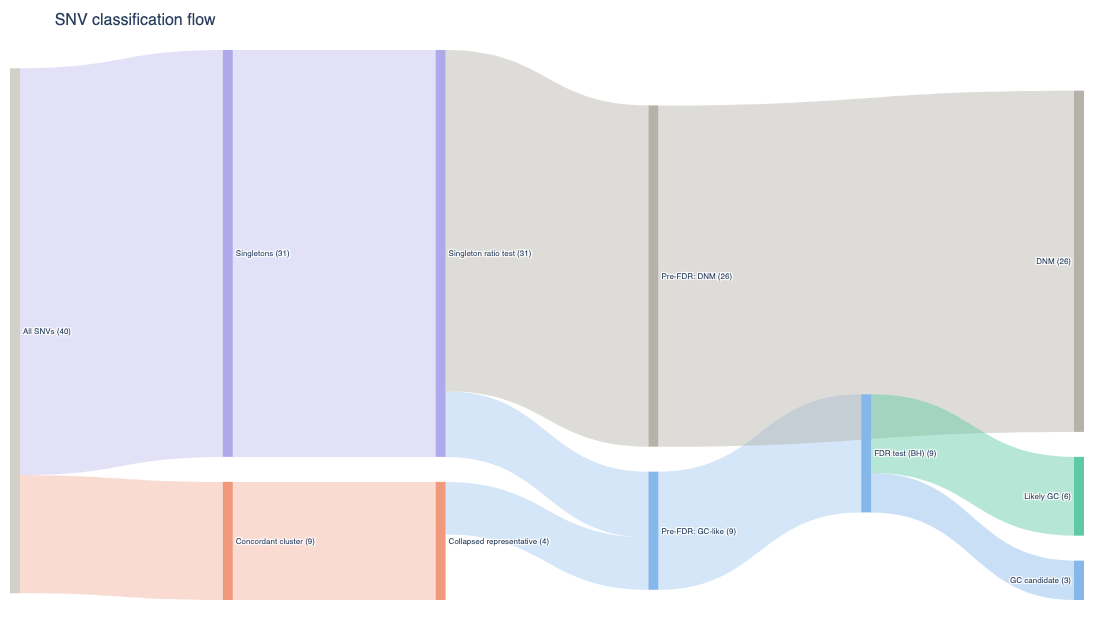

singletons              31
conc_snvs                9
conc_clusters            4
part_snvs                0
nodon_snvs               0
singleton_to_gc_like     5
singleton_to_dnm        26
partial_to_gc_like       0
partial_to_dnm           0
nodon_to_gc_like         0
pre_fdr_gc               9
pre_fdr_dnm             26
fdr_to_likely_gc         6
fdr_to_gc_candidate      3
fdr_to_dnm               0
n_likely_gc              6
n_gc_candidate           3
n_dnm                   26
problems                []
dtype: object


In [18]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def _rgba(hex_color, alpha):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def _norm_str_series(df, col):
    """Return a normalized string series; missing columns become empty strings."""
    if col not in df.columns:
        return pd.Series("", index=df.index, dtype="object")
    s = df[col]
    return (
        s.fillna("")
         .astype(str)
         .str.strip()
         .replace({"nan": "", "None": "", "<NA>": ""})
    )


def build_sankey_counts(merged, merged_dedup, strict=True):
    """
    Trace rows through the pipeline and return consistent counts for the Sankey.

    Key rule:
      - Final FDR split uses `final_class`, not `gc_fdr_significant`,
        so final node labels and link widths match.

    Parameters
    ----------
    merged : pd.DataFrame
        Pre-dedup table used for entry-lane counts.
    merged_dedup : pd.DataFrame
        Final per-event table after dedup / collapse / classification.
    strict : bool
        If True, raise an error when flow balances do not add up.
        If False, keep going and report counts anyway.

    Returns
    -------
    dict
        Count dictionary used to build the Sankey.
    """
    m = merged.copy()
    d = merged_dedup.copy()

    req_m = ["cluster_size", "putative_class", "snv_cluster_id"]
    req_d = ["cluster_size", "putative_class", "final_class"]

    missing_m = [c for c in req_m if c not in m.columns]
    missing_d = [c for c in req_d if c not in d.columns]

    if missing_m:
        raise KeyError(f"`merged` is missing required columns: {missing_m}")
    if missing_d:
        raise KeyError(f"`merged_dedup` is missing required columns: {missing_d}")


    m_put = _norm_str_series(m, "putative_class")
    d_put = _norm_str_series(d, "putative_class")
    d_orig = _norm_str_series(d, "original_putative_class")
    d_final = _norm_str_series(d, "final_class")

    m_cluster_size = pd.to_numeric(m["cluster_size"], errors="coerce")
    d_cluster_size = pd.to_numeric(d["cluster_size"], errors="coerce")

    singletons_mask = m_cluster_size.eq(1)

    conc_snvs_mask = (
        m_cluster_size.gt(1) &
        m_put.eq("GC_candidate_cluster")
    )
    part_snvs_mask = (
        m_cluster_size.gt(1) &
        m_put.eq("GC_candidate_cluster_partial")
    )
    nodon_snvs_mask = (
        m_cluster_size.gt(1) &
        m_put.eq("GC_candidate_cluster_no_donor")
    )

    n_singletons = int(singletons_mask.sum())
    n_conc_snvs = int(conc_snvs_mask.sum())
    n_part_snvs = int(part_snvs_mask.sum())
    n_nodon_snvs = int(nodon_snvs_mask.sum())

    n_conc_clusters = int(
        m.loc[conc_snvs_mask, "snv_cluster_id"].dropna().nunique()
    )


    singleton_mask = (
        d_cluster_size.eq(1) &
        d_orig.eq("")
    )
    singleton_to_gc_like = int((singleton_mask & d_put.ne("DNM")).sum())
    singleton_to_dnm = int((singleton_mask & d_put.eq("DNM")).sum())

    partial_mask = d_orig.eq("GC_candidate_cluster_partial")
    partial_to_gc_like = int((partial_mask & d_put.ne("DNM")).sum())
    partial_to_dnm = int((partial_mask & d_put.eq("DNM")).sum())

    nodon_mask = (
        d_cluster_size.gt(1) &
        d_orig.eq("") &
        d_put.ne("DNM") &
        d_put.ne("GC_candidate_cluster")
    )
    nodon_to_gc_like = int(nodon_mask.sum())

    pre_fdr_gc = int(d_put.ne("DNM").sum())
    pre_fdr_dnm = int(d_put.eq("DNM").sum())

    incoming_pre_fdr_gc = (
        singleton_to_gc_like +
        n_conc_clusters +
        partial_to_gc_like +
        nodon_to_gc_like
    )
    incoming_pre_fdr_dnm = (
        singleton_to_dnm +
        partial_to_dnm
    )

    gc_like_mask = d_put.ne("DNM")

    fdr_to_likely_gc = int((gc_like_mask & d_final.eq("Likely_GC")).sum())
    fdr_to_gc_candidate = int((gc_like_mask & d_final.eq("GC_candidate")).sum())
    fdr_to_dnm = int((gc_like_mask & d_final.eq("DNM")).sum())

    n_likely_gc = int(d_final.eq("Likely_GC").sum())
    n_gc_candidate = int(d_final.eq("GC_candidate").sum())
    n_dnm = int(d_final.eq("DNM").sum())

    problems = []

    if incoming_pre_fdr_gc != pre_fdr_gc:
        problems.append(
            f"Pre-FDR GC-like imbalance: incoming={incoming_pre_fdr_gc}, node={pre_fdr_gc}"
        )

    if incoming_pre_fdr_dnm != pre_fdr_dnm:
        problems.append(
            f"Pre-FDR DNM imbalance: incoming={incoming_pre_fdr_dnm}, node={pre_fdr_dnm}"
        )

    if (fdr_to_likely_gc + fdr_to_gc_candidate + fdr_to_dnm) != pre_fdr_gc:
        problems.append(
            "FDR split imbalance: "
            f"outgoing={fdr_to_likely_gc + fdr_to_gc_candidate + fdr_to_dnm}, "
            f"node={pre_fdr_gc}"
        )

    if (pre_fdr_dnm + fdr_to_dnm) != n_dnm:
        problems.append(
            "Final DNM imbalance: "
            f"pre_FDR_DNM + FDR_to_DNM = {pre_fdr_dnm + fdr_to_dnm}, final DNM node={n_dnm}"
        )

    if strict and problems:
        raise ValueError("Sankey count mismatch:\n- " + "\n- ".join(problems))

    return {
        "singletons": n_singletons,
        "conc_snvs": n_conc_snvs,
        "conc_clusters": n_conc_clusters,
        "part_snvs": n_part_snvs,
        "nodon_snvs": n_nodon_snvs,

        "singleton_to_gc_like": singleton_to_gc_like,
        "singleton_to_dnm": singleton_to_dnm,
        "partial_to_gc_like": partial_to_gc_like,
        "partial_to_dnm": partial_to_dnm,
        "nodon_to_gc_like": nodon_to_gc_like,

        "pre_fdr_gc": pre_fdr_gc,
        "pre_fdr_dnm": pre_fdr_dnm,

        "fdr_to_likely_gc": fdr_to_likely_gc,
        "fdr_to_gc_candidate": fdr_to_gc_candidate,
        "fdr_to_dnm": fdr_to_dnm,

        "n_likely_gc": n_likely_gc,
        "n_gc_candidate": n_gc_candidate,
        "n_dnm": n_dnm,

        "problems": problems,
    }


def _lookup_count(name, c):
    """Map each node name to the count shown in its label."""
    table = {
        "All SNVs": (
            c["singletons"] +
            c["conc_snvs"] +
            c["part_snvs"] +
            c["nodon_snvs"]
        ),
        "Singletons": c["singletons"],
        "Concordant cluster": c["conc_snvs"],
        "Partial cluster": c["part_snvs"],
        "No-donor cluster": c["nodon_snvs"],
        "Singleton ratio test": c["singletons"],
        "Collapsed representative": c["conc_clusters"],
        "Partial reclassify": c["part_snvs"],
        "Pre-FDR: GC-like": c["pre_fdr_gc"],
        "Pre-FDR: DNM": c["pre_fdr_dnm"],
        "FDR test (BH)": c["pre_fdr_gc"],
        "Likely GC": c["n_likely_gc"],
        "GC candidate": c["n_gc_candidate"],
        "DNM": c["n_dnm"],
    }
    return table.get(name, 0)


def make_sankey(merged, merged_dedup, title="SNV classification flow", strict=True):
    """
    Build the Sankey diagram.

    Parameters
    ----------
    merged : pd.DataFrame
    merged_dedup : pd.DataFrame
    title : str
    strict : bool
        If True, raise if flows do not balance.
        If False, continue even if the counts are imperfect.
    """
    c = build_sankey_counts(merged, merged_dedup, strict=strict)


    SINGLETON = "#AFA9EC"  
    CLUSTER   = "#F0997B" 
    GC_LIKE   = "#85B7EB"  
    LIKELY_GC = "#5DCAA5"   
    DNM_COLOR = "#B4B2A9"  
    NEUTRAL   = "#D3D1C7"  

    nodes = [
        ("All SNVs",                  NEUTRAL),   
        ("Singletons",                SINGLETON), 
        ("Concordant cluster",        CLUSTER),   
        ("Partial cluster",           CLUSTER),    
        ("No-donor cluster",          CLUSTER),   
        ("Singleton ratio test",      SINGLETON),  
        ("Collapsed representative",  CLUSTER),   
        ("Partial reclassify",        CLUSTER),   
        ("Pre-FDR: GC-like",          GC_LIKE),    
        ("Pre-FDR: DNM",              DNM_COLOR),  
        ("FDR test (BH)",             GC_LIKE),    
        ("Likely GC",                 LIKELY_GC),  
        ("GC candidate",              GC_LIKE),    
        ("DNM",                       DNM_COLOR), 
    ]

    labels = [f"{name} ({_lookup_count(name, c)})" for name, _ in nodes]
    colors = [color for _, color in nodes]

    link_color_by_target = {
        1: _rgba(SINGLETON, 0.35),
        2: _rgba(CLUSTER, 0.35),
        3: _rgba(CLUSTER, 0.35),
        4: _rgba(CLUSTER, 0.35),
        5: _rgba(SINGLETON, 0.35),
        6: _rgba(CLUSTER, 0.35),
        7: _rgba(CLUSTER, 0.35),
        8: _rgba(GC_LIKE, 0.35),
        9: _rgba(DNM_COLOR, 0.45),
        10: _rgba(GC_LIKE, 0.35),
        11: _rgba(LIKELY_GC, 0.45),
        12: _rgba(GC_LIKE, 0.45),
        13: _rgba(DNM_COLOR, 0.45),
    }


    raw_links = [
        (0, 1, c["singletons"]),
        (0, 2, c["conc_snvs"]),
        (0, 3, c["part_snvs"]),
        (0, 4, c["nodon_snvs"]),
        (1, 5, c["singletons"]),
        (2, 6, c["conc_snvs"]),    
        (3, 7, c["part_snvs"]),
        (5, 8, c["singleton_to_gc_like"]),
        (5, 9, c["singleton_to_dnm"]),
        (6, 8, c["conc_clusters"]),
        (7, 8, c["partial_to_gc_like"]),
        (7, 9, c["partial_to_dnm"]),
        (4, 8, c["nodon_to_gc_like"]),
        (8, 10, c["pre_fdr_gc"]),
        (9, 13, c["pre_fdr_dnm"]),
        (10, 11, c["fdr_to_likely_gc"]),
        (10, 12, c["fdr_to_gc_candidate"]),
        (10, 13, c["fdr_to_dnm"]),
    ]

    links = [(s, t, v) for (s, t, v) in raw_links if v > 0]

    sources = [s for s, _, _ in links]
    targets = [t for _, t, _ in links]
    values = [v for _, _, v in links]
    lcolors = [link_color_by_target[t] for _, t, _ in links]

    fig = go.Figure(go.Sankey(
        arrangement="perpendicular",
        node=dict(
            pad=25,
            thickness=10,
            line=dict(color="rgba(0,0,0,0)", width=0),
            label=labels,
            color=colors,
            hovertemplate="%{label}<extra></extra>",
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=lcolors,
            hovertemplate="%{source.label} → %{target.label}<br>count: %{value}<extra></extra>",
        ),
    ))

    fig.update_layout(
        title=dict(text=title, font=dict(size=16)),
        font=dict(family="Helvetica, Arial, sans-serif", size=8),
        height=620,
        margin=dict(l=10, r=10, t=50, b=20),
    )

    return fig, c


fig, counts = make_sankey(
    merged,
    merged_dedup,
    title="SNV classification flow",
    strict=True,
)

fig.show()

print(pd.Series(counts))
fig.write_image(
    "/DNM_sankey.pdf",
    width=800,
    height=420,
)